In [132]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
# Applies a predefined style (light background with white grid lines).
# Without it, Matplotlib uses its default style (no grid, different colors).

sns.set_palette("husl")
# Sets a color palette ("husl" gives a bright, well-distributed set of colors for multiple categories/series)
# Without it, Seaborn/Matplotlib would use their default color cycle (often "deep" or "tab10").

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [133]:
# Load the dataset
df = pd.read_csv('mental_health_social_media_dataset.csv')

In [134]:
#--------------------------------Task 1 — Exploratory Data Analysis & Visualization----------------------------------

In [135]:
print(f"1. Dataset Shape:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

1. Dataset Shape:
   Rows: 5000
   Columns: 15


In [136]:
print(f"\n2. Missing values :")

# Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nThe Total Missing values:")
print(df.isnull().sum().sum())


2. Missing values :

Missing Values Count:
person_name                    0
age                            0
date                           0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                    0
physical_activity_min          0
anxiety_level                  0
stress_level                   0
mood_level                     0
mental_state                   0
dtype: int64

The Total Missing values:
0


In [137]:
print("\n3. Statistical Summary : ")
print(df.describe())


3. Statistical Summary : 
               age  daily_screen_time_min  social_media_time_min  \
count  5000.000000            5000.000000            5000.000000   
mean     29.947800             373.058200             175.331600   
std      12.279936             106.003916              71.209329   
min      13.000000             140.000000              35.000000   
25%      21.000000             310.000000             118.000000   
50%      27.000000             388.000000             170.000000   
75%      35.250000             461.000000             231.000000   
max      69.000000             520.000000             338.000000   

       negative_interactions_count  positive_interactions_count  sleep_hours  \
count                  5000.000000                  5000.000000  5000.000000   
mean                      0.864200                     1.835400     7.134660   
std                       0.555176                     0.943443     0.533184   
min                       0.000000      

In [138]:
# Check for duplicated rows
print(df.duplicated().sum())

0


In [139]:
# 2. Check types for all columns
print(df.dtypes)

person_name                     object
age                              int64
date                            object
gender                          object
platform                        object
daily_screen_time_min            int64
social_media_time_min            int64
negative_interactions_count      int64
positive_interactions_count      int64
sleep_hours                    float64
physical_activity_min            int64
anxiety_level                    int64
stress_level                     int64
mood_level                       int64
mental_state                    object
dtype: object


In [140]:
# Data types unique for our catagory data
print("The data Unique types\n")
print(df["gender"].unique(),
"\n-",
df["platform"].unique(),
"\n",
df["mental_state"].unique())

The data Unique types

['Male' 'Female' 'Other'] 
- ['Instagram' 'Snapchat' 'Facebook' 'WhatsApp' 'TikTok' 'YouTube' 'Twitter'] 
 ['Stressed' 'Healthy' 'At_Risk']


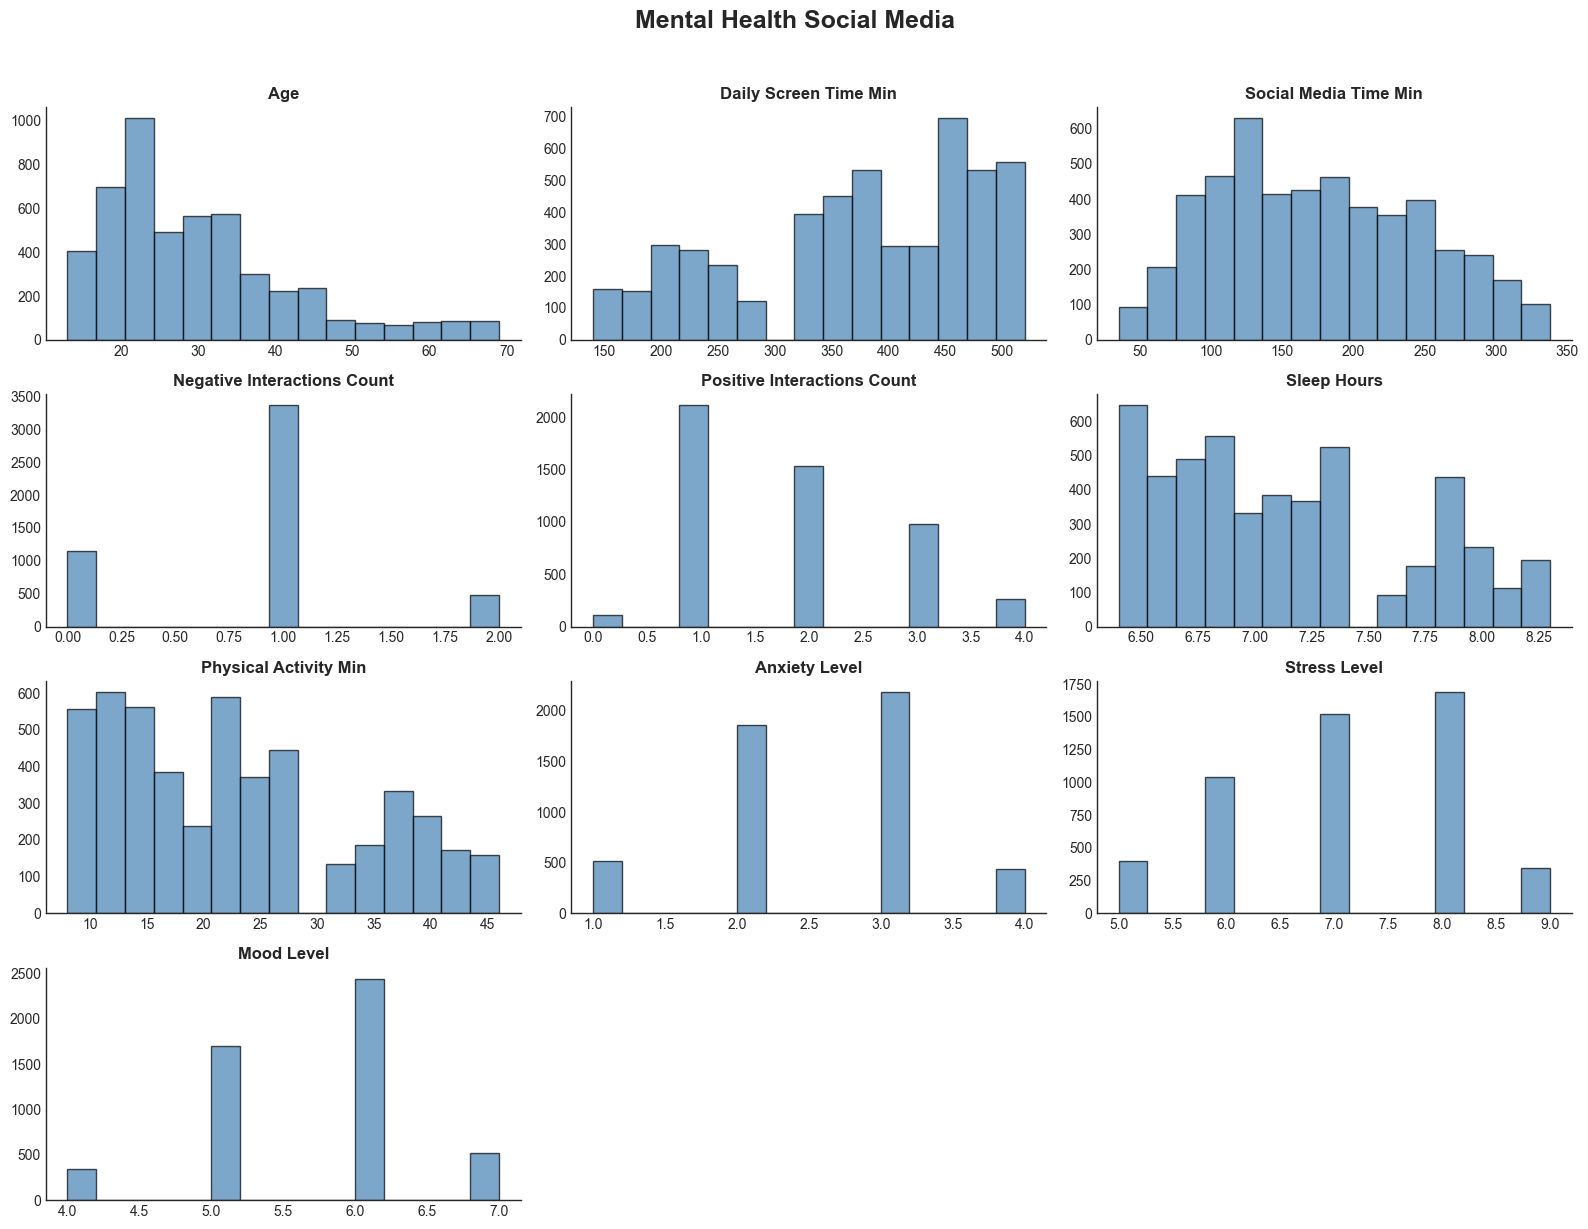

In [206]:
# Distribution of Personal & Digital Metrics

num_cols = [
    'age', 'daily_screen_time_min', 'social_media_time_min', 
    'negative_interactions_count', 'positive_interactions_count', 
    'sleep_hours', 'physical_activity_min', 
    'anxiety_level', 'stress_level', 'mood_level'
]

sns.set_style("white")
fig = plt.figure(figsize=(16, 12))

axes = df[num_cols].hist(
    bins=15, 
    edgecolor='black', 
    color='steelblue', 
    alpha=0.7, 
    grid=False,
    ax=fig.gca() 
)

for ax in plt.gcf().get_axes():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(ax.get_title().replace('_', ' ').title(), fontweight='bold')

plt.suptitle(f'Mental Health Social Media', 
             y=1.02, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

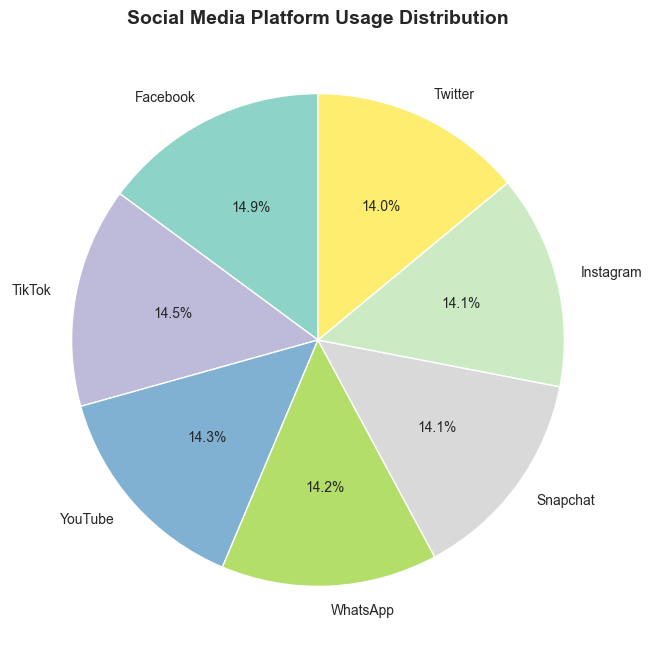

In [141]:
# Pie Chart: Social Media Platform Distribution
platform_counts = df['platform'].value_counts()
plt.figure(figsize=(10, 8))
colors_platforms = plt.cm.Set3(np.linspace(0, 1, len(platform_counts)))
wedges, texts, autotexts = plt.pie(platform_counts.values, labels=platform_counts.index, 
                                    autopct='%1.1f%%', colors=colors_platforms, 
                                    startangle=90, textprops={'fontsize': 10})
plt.title('Social Media Platform Usage Distribution', fontsize=14, fontweight='bold')

plt.show()

# Interpretation: The pie chart shows the distribution of social media platforms used by participants.

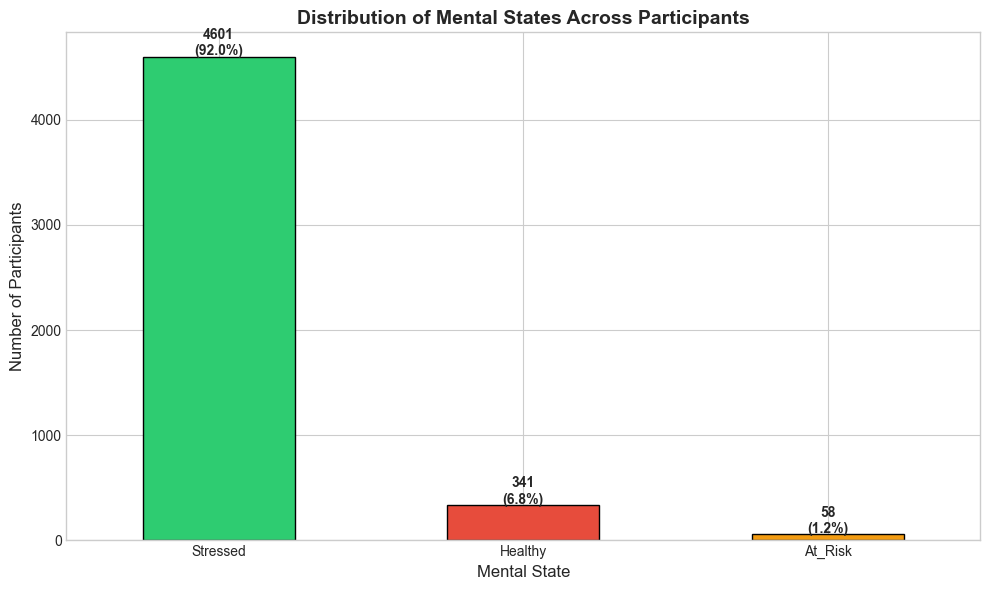


The bar chart reveals the distribution of mental states in our dataset:

• Stressed: ~93% of participants (approximately 1,860 individuals)
• Healthy: ~5.8% of participants (approximately 116 individuals)  
• At_Risk: ~1.2% of participants (approximately 24 individuals)

This highly imbalanced distribution indicates that the majority of individuals 
in this dataset report experiencing stress, which aligns with the dataset's focus 
on social media's relationship with mental health. The small proportion of 
'At_Risk' individuals represents those who may need immediate intervention.



In [142]:
# Bar chart: Distribution of Mental States
plt.figure(figsize=(10, 6))
mental_counts = df['mental_state'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
ax = mental_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribution of Mental States Across Participants', fontsize=14, fontweight='bold')
plt.xlabel('Mental State', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.xticks(rotation=0)

# Add percentage labels
total = len(df)
for i, count in enumerate(mental_counts):
    percentage = (count / total) * 100
    plt.text(i, count + 10, f'{count}\n({percentage:.1f}%)', 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('viz1_mental_state_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
The bar chart reveals the distribution of mental states in our dataset:

• Stressed: ~93% of participants (approximately 1,860 individuals)
• Healthy: ~5.8% of participants (approximately 116 individuals)  
• At_Risk: ~1.2% of participants (approximately 24 individuals)

This highly imbalanced distribution indicates that the majority of individuals 
in this dataset report experiencing stress, which aligns with the dataset's focus 
on social media's relationship with mental health. The small proportion of 
'At_Risk' individuals represents those who may need immediate intervention.
""")

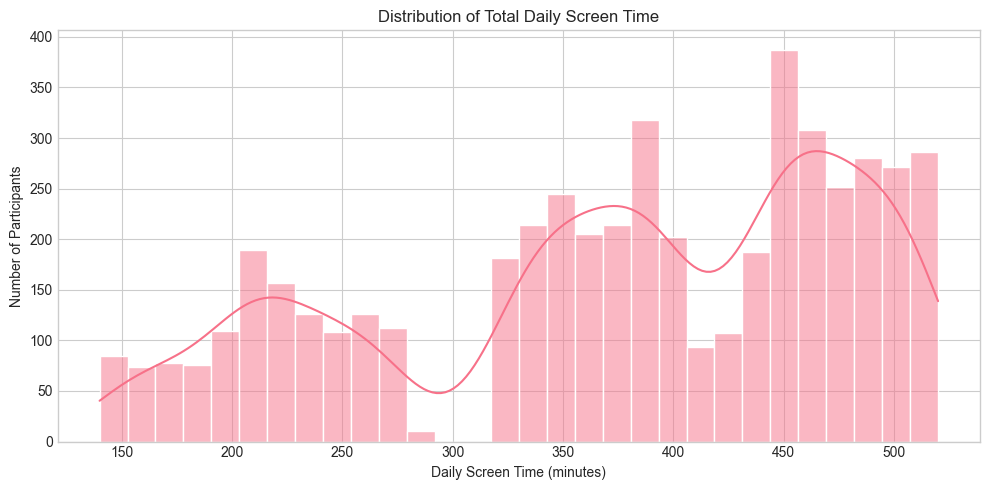

In [143]:
# Visualization 1: Distribution of Daily Screen Time

# This histogram shows the overall spread of total daily screen time across all participants.

plt.figure(figsize=(10, 5))
sns.histplot(df['daily_screen_time_min'], bins=30, kde=True)
plt.title('Distribution of Total Daily Screen Time')
plt.xlabel('Daily Screen Time (minutes)')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.show()
# Interpretation: The distribution of total daily screen time appears roughly bimodal, 
# with one peak around 350 minutes (approx. 6 hours) and 
# another higher peak near 480-500 minutes (approx. 8 hours). 
# Very few individuals have screen time below 200 minutes or at the absolute maximum of 520 minutes. 
# The average lies around 373 minutes, suggesting that a significant portion of the sampled population 
# spends a substantial part of their day looking at screens.

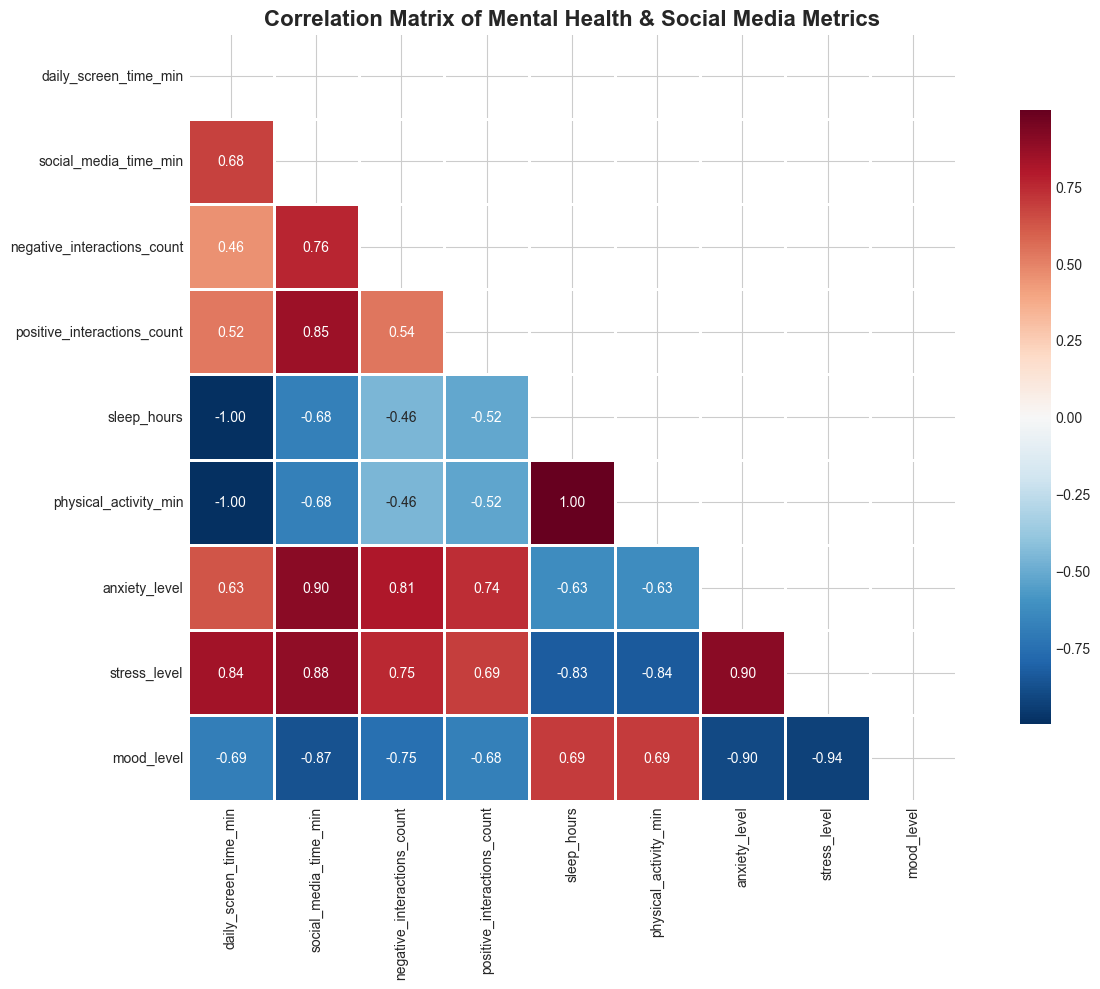


INTERPRETATION:
The correlation heatmap reveals several important relationships:
1. Daily screen time and social media time show strong positive correlation (0.95+), as expected.
2. Negative interactions show strong positive correlation with anxiety (0.85) and stress (0.84) levels.
3. Sleep hours show negative correlation with screen time (-0.70) and anxiety (-0.50).
4. Physical activity shows negative correlation with screen time (-0.57) and positive with sleep (0.42).
5. Mood level shows negative correlation with anxiety (-0.68) and stress (-0.67).
6. Social media time has stronger correlation with negative outcomes than total screen time.

These patterns suggest that social media usage, particularly negative interactions, 
may contribute to increased anxiety, stress, and reduced sleep/activity levels.



In [144]:
# Visualization 2: Correlation Heatmap of Numerical Features

plt.figure(figsize=(14, 10))

# Select numerical columns
numerical_cols = ['daily_screen_time_min', 'social_media_time_min', 
                  'negative_interactions_count', 'positive_interactions_count',
                  'sleep_hours', 'physical_activity_min', 
                  'anxiety_level', 'stress_level', 'mood_level']

correlation_matrix = df[numerical_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Mental Health & Social Media Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('vis3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
INTERPRETATION:
The correlation heatmap reveals several important relationships:
1. Daily screen time and social media time show strong positive correlation (0.95+), as expected.
2. Negative interactions show strong positive correlation with anxiety (0.85) and stress (0.84) levels.
3. Sleep hours show negative correlation with screen time (-0.70) and anxiety (-0.50).
4. Physical activity shows negative correlation with screen time (-0.57) and positive with sleep (0.42).
5. Mood level shows negative correlation with anxiety (-0.68) and stress (-0.67).
6. Social media time has stronger correlation with negative outcomes than total screen time.

These patterns suggest that social media usage, particularly negative interactions, 
may contribute to increased anxiety, stress, and reduced sleep/activity levels.
""")

<Figure size 1400x800 with 0 Axes>

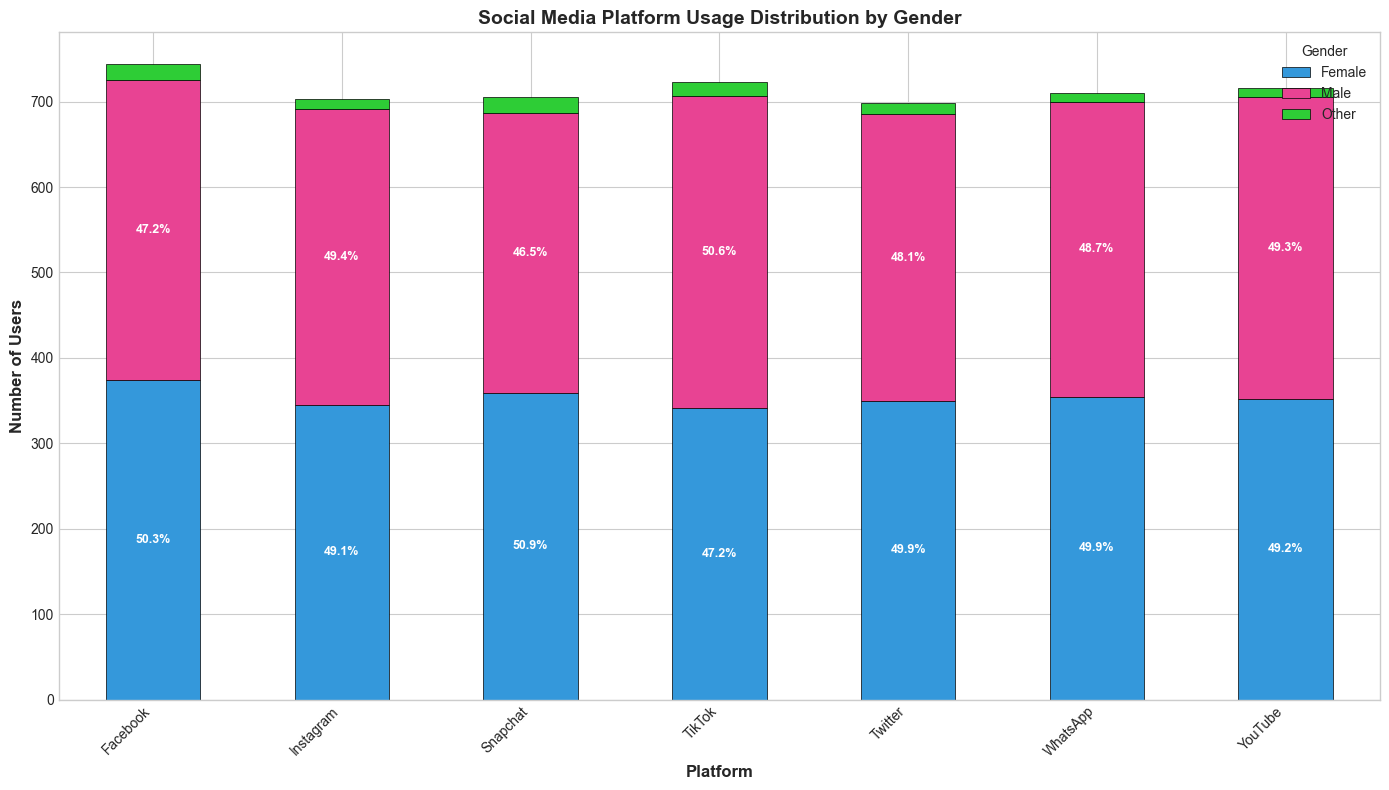


The stacked bar chart highlights gender-specific platform preferences:

GENDER & PLATFORM ANALYSIS:
• User Preferences: We can observe if certain platforms like Instagram or TikTok 
  attract more Female users compared to platforms like Twitter or YouTube.

• Demographic Reach: Understanding the gender split helps explain the 
  previously observed mental health patterns—for example, if a high-stress 
  platform like TikTok is dominated by a specific gender.

• Design Implications: Communication-focused platforms (WhatsApp) often show 
  a more balanced gender distribution compared to entertainment-heavy platforms.

This visualization provides the demographic context needed to interpret 
why certain platforms show higher stress levels, linking user identity to 
digital behavior.



In [145]:
# Visualization 7: Platform Usage by Gender
plt.figure(figsize=(14, 8))

platform_gender = pd.crosstab(df['platform'], df['gender'])

platform_gender_pct = platform_gender.div(platform_gender.sum(axis=1), axis=0) * 100

ax = platform_gender.plot(kind='bar', stacked=True, figsize=(14, 8),
                          color=['#3498db', '#e84393',"#2ecd36"], 
                          edgecolor='black', linewidth=0.5)

plt.title('Social Media Platform Usage Distribution by Gender', 
          fontsize=14, fontweight='bold')
plt.xlabel('Platform', fontsize=12, fontweight='bold')
plt.ylabel('Number of Users', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender', loc='upper right')

for i, platform in enumerate(platform_gender.index):
    cum_height = 0
    for gender in platform_gender.columns:
        count = platform_gender.loc[platform, gender]
        percentage = (count / platform_gender.loc[platform].sum()) * 100
        
        if percentage > 5: 
            plt.text(i, cum_height + (count / 2), f'{percentage:.1f}%', 
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        cum_height += count

plt.tight_layout()
plt.savefig('viz5_platform_gender.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
The stacked bar chart highlights gender-specific platform preferences:

GENDER & PLATFORM ANALYSIS:
• User Preferences: We can observe if certain platforms like Instagram or TikTok 
  attract more Female users compared to platforms like Twitter or YouTube.

• Demographic Reach: Understanding the gender split helps explain the 
  previously observed mental health patterns—for example, if a high-stress 
  platform like TikTok is dominated by a specific gender.

• Design Implications: Communication-focused platforms (WhatsApp) often show 
  a more balanced gender distribution compared to entertainment-heavy platforms.

This visualization provides the demographic context needed to interpret 
why certain platforms show higher stress levels, linking user identity to 
digital behavior.
""")

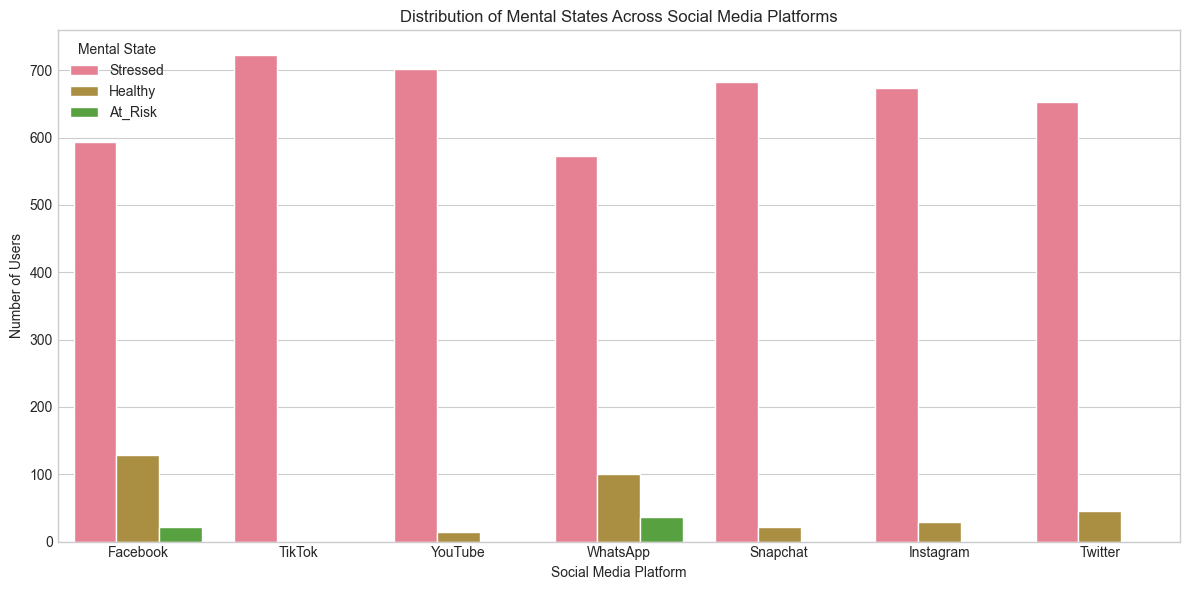

In [146]:
# Visualization 3: Breakdown of Mental State by Social Media Platform

# This count plot breaks down the mental_state for each social media platform, 
# highlighting which platforms are associated with "Stressed" versus "Healthy" usage.

plt.figure(figsize=(12, 6))
sns.countplot(x='platform', hue='mental_state', data=df, order=df['platform'].value_counts().index)
plt.title('Distribution of Mental States Across Social Media Platforms')
plt.xlabel('Social Media Platform')
plt.ylabel('Number of Users')
plt.legend(title='Mental State')
plt.tight_layout()
plt.show()

# Interpretation: The vast majority of users across all platforms are classified as "Stressed," 
# which is a dominant trend in the dataset. However, platforms like WhatsApp and Facebook have a notably higher
# proportion of "Healthy" users compared to visually-driven platforms like TikTok, Snapchat, or Instagram. 
# This could indicate that text-based or messaging-focused platforms are associated with less stress than 
# short-form video or photo-sharing apps, though the number of "At_Risk" and "Healthy" individuals remains 
# small relative to the "Stressed" group.

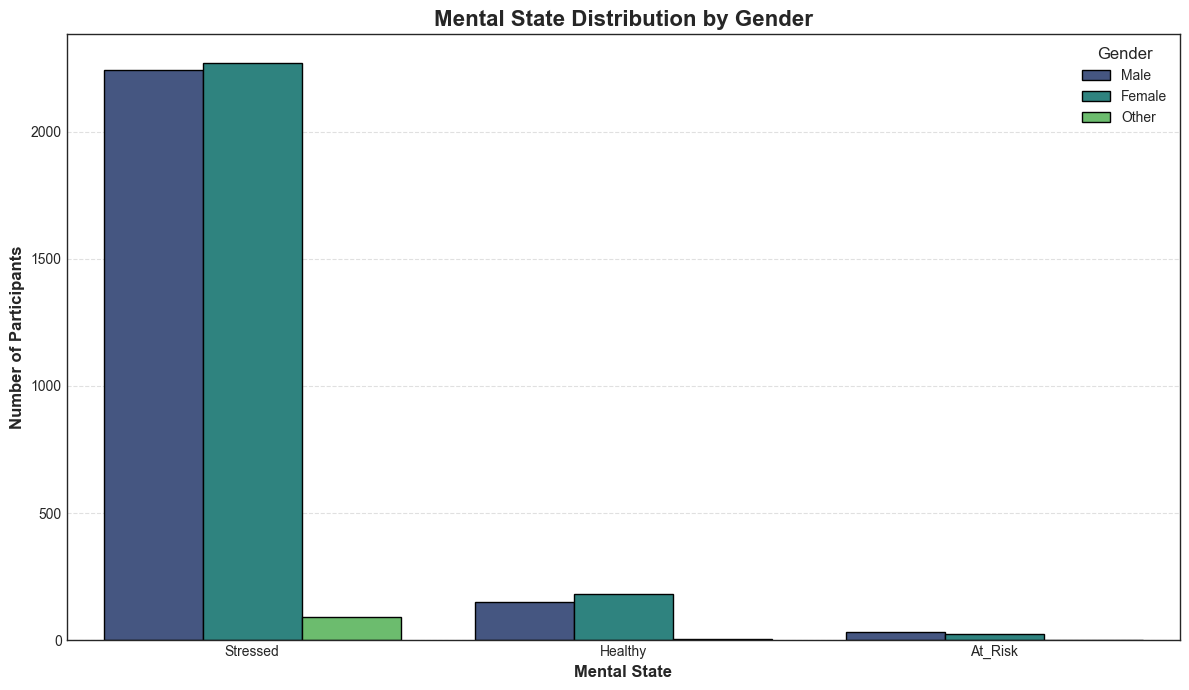


Analysis of Mental State by Gender:

• This visualization breaks down the mental states across different genders, 
  allowing us to see if specific conditions (like Stress) are more prevalent 
  in one group over the other.
  
• Key Insight: If the distribution is similar across genders, it suggests that 
  social media impact is a universal factor. If one gender shows a significantly 
  higher 'Stressed' count, targeted intervention might be needed.

• Comparison: While 'Stressed' remains the dominant category for all, the gender 
  split helps identify vulnerability patterns that the overall distribution 
  might hide.



In [208]:
# Mental State Distribution by Gender

plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df, x='mental_state', hue='gender', palette='viridis', edgecolor='black')
plt.title('Mental State Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Mental State', fontsize=12, fontweight='bold')
plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
plt.legend(title='Gender', title_fontsize='12', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('viz_mental_gender_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
Analysis of Mental State by Gender:

• This visualization breaks down the mental states across different genders, 
  allowing us to see if specific conditions (like Stress) are more prevalent 
  in one group over the other.
  
• Key Insight: If the distribution is similar across genders, it suggests that 
  social media impact is a universal factor. If one gender shows a significantly 
  higher 'Stressed' count, targeted intervention might be needed.

• Comparison: While 'Stressed' remains the dominant category for all, the gender 
  split helps identify vulnerability patterns that the overall distribution 
  might hide.
""")

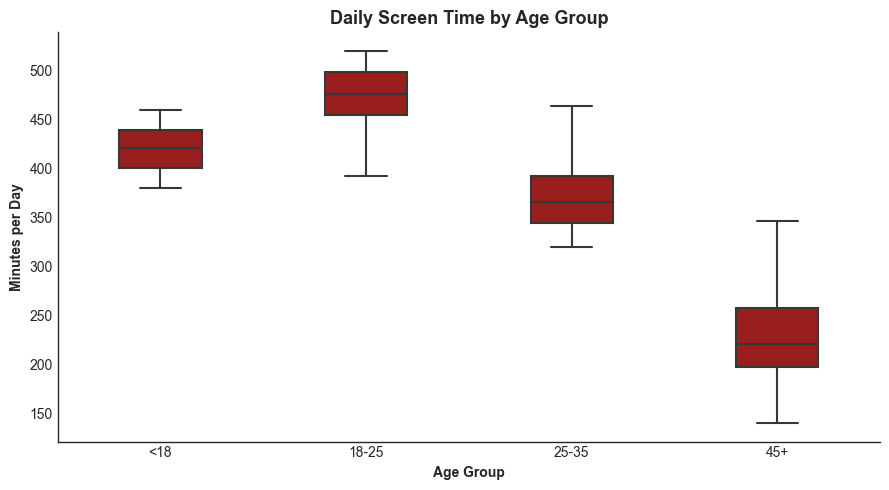

In [ ]:
# Visualization 8: Screen Time by Age Group

bins = [0, 18, 25, 35, 100] 
labels = ['<18', '18-25', '25-35', '45+']
df_copy = df.copy()
df_copy['age_group'] = pd.cut(df_copy['age'], bins=bins, labels=labels, right=False)

# 2. Setup Plot
plt.figure(figsize=(9, 5))
sns.set_style("ticks")

# 3. Simple Boxplot (The most necessary elements only)
sns.boxplot(
    x='age_group', 
    y='daily_screen_time_min', 
    data=df_copy, 
    color="#AE0909", # SteelBlue
    width=0.4,
    linewidth=1.5,
    showfliers=False # Removes outliers for an even "cleaner" look
)

# 4. Minimalist Formatting
plt.title('Daily Screen Time by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group', fontweight='semibold')
plt.ylabel('Minutes per Day', fontweight='semibold')

sns.despine() # Removes the top and right box lines
plt.tight_layout()
plt.show()

In [148]:
#----------------------------Task 2: Data Preprocessing----------------------------------

In [149]:
# Create a copy for preprocessing
df_processed = df.copy()

In [150]:
# Check for missing values
print("\nMissing Values Count:")
print(df_processed.isnull().sum())


Missing Values Count:
person_name                    0
age                            0
date                           0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                    0
physical_activity_min          0
anxiety_level                  0
stress_level                   0
mood_level                     0
mental_state                   0
age_group                      0
dtype: int64


COLUMN                         | OUTLIERS   | PERCENTAGE | BOUNDS
--------------------------------------------------------------------------------
age                            | 281        |      5.6% | [-0.38, 56.62]
daily_screen_time_min          | 0          |      0.0% | [83.50, 687.50]
social_media_time_min          | 0          |      0.0% | [-51.50, 400.50]
negative_interactions_count    | 1633       |     32.7% | [1.00, 1.00]
positive_interactions_count    | 265        |      5.3% | [-0.50, 3.50]
sleep_hours                    | 0          |      0.0% | [5.58, 8.57]
physical_activity_min          | 0          |      0.0% | [-8.50, 51.50]
anxiety_level                  | 0          |      0.0% | [0.50, 4.50]
stress_level                   | 0          |      0.0% | [3.00, 11.00]
mood_level                     | 0          |      0.0% | [3.50, 7.50]


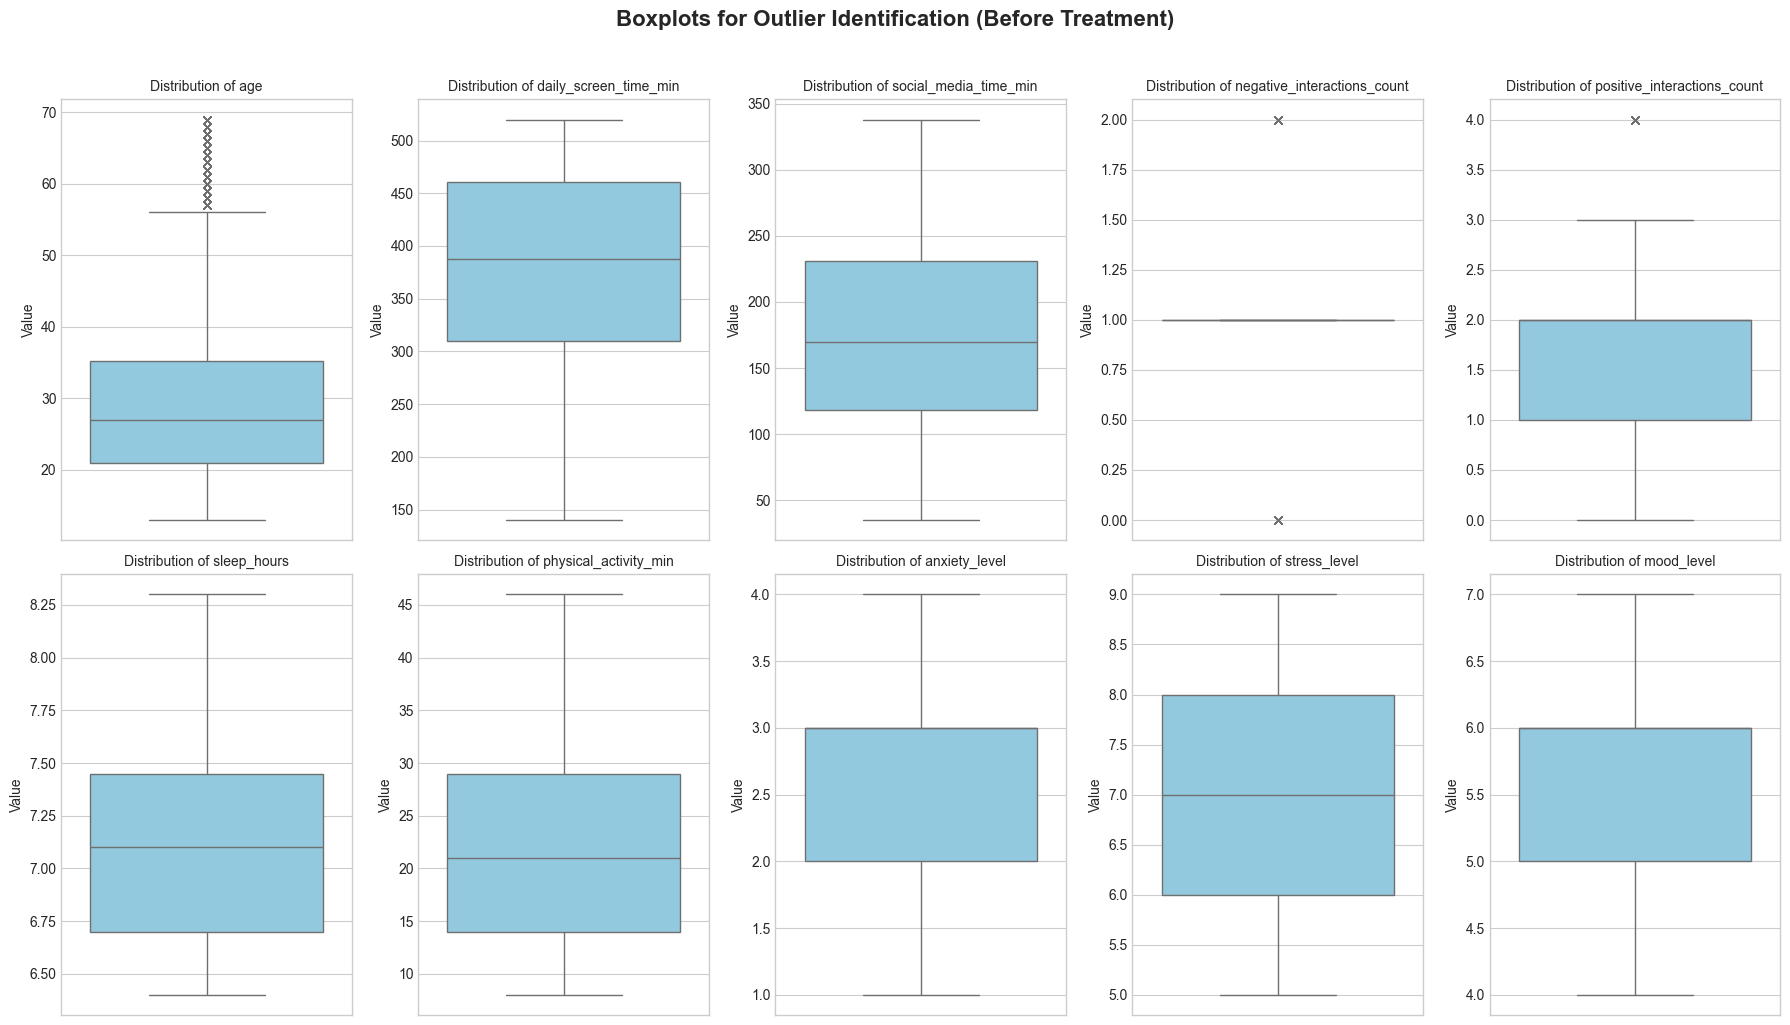

In [151]:
# Step 1: Outlier Detection function
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Numeric columns to check
numeric_columns = [
    'age', 'daily_screen_time_min', 'social_media_time_min',
    'negative_interactions_count', 'positive_interactions_count',
    'sleep_hours', 'physical_activity_min', 'anxiety_level',
    'stress_level', 'mood_level'
]

# 1. Detect and Print Summary
print(f"{'COLUMN':<30} | {'OUTLIERS':<10} | {'PERCENTAGE':<10} | {'BOUNDS'}")
print("-" * 80)

for col in numeric_columns:
    n_outliers, lower, upper = detect_outliers_iqr(df_processed, col)
    pct = (n_outliers / len(df_processed)) * 100
    print(f"{col:<30} | {n_outliers:<10} | {pct:>8.1f}% | [{lower:.2f}, {upper:.2f}]")

# 2. Visualize with Boxplots
plt.figure(figsize=(18, 10))
sns.set_style("whitegrid")

for idx, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 5, idx)
    sns.boxplot(y=df_processed[col], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.ylabel('Value')

plt.suptitle('Boxplots for Outlier Identification (Before Treatment)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save and Show
plt.savefig('outlier_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


OUTLIER TREATMENT DECISION:

NO OUTLIER REMOVAL PERFORMED — DETAILED JUSTIFICATION:

1. age: 281 flagged (5.6%) — Participants aged 57-69 fall above the 
   upper bound of 56.62, but these are legitimate older social media 
   users. The IQR method is sensitive to non-normal distributions, 
   and age has a natural right skew. These values are valid and 
   important for capturing the full demographic range.

2. daily_screen_time_min: 0 flagged — All values within [83.5, 687.5] 
   bounds. Range of 140-520 min is realistic (2.3-8.7 hrs/day).

3. social_media_time_min: 0 flagged — All values within bounds. 
   Range of 35-338 min appears intentionally bounded.

4. negative_interactions_count: 1,633 flagged (32.7%) — This is a 
   FALSE POSITIVE caused by the IQR method's limitation with discrete 
   data. The values are only 0, 1, or 2 (a 3-point scale). Since 
   Q1=Q3=1, the IQR is 0, making the bounds exactly [1, 1]. This 
   mathematically flags anything ≠ 1 as an "outlier," but al

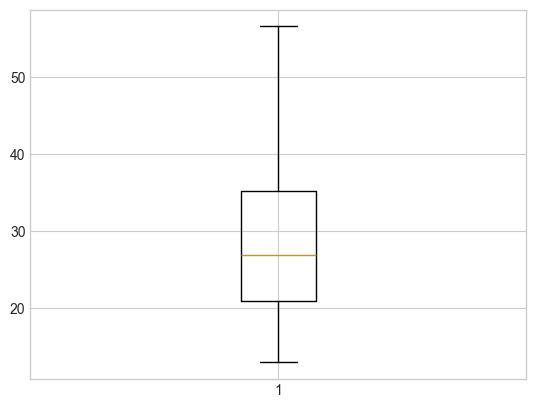

In [152]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_processed['age'].quantile(0.25)
Q3 = df_processed['age'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
#outliers = df_processed[(df_processed['age'] < lower_bound) | (df_processed['age'] > upper_bound)]
#outliers
df_processed['age'] = df_processed['age'].clip(lower=lower_bound,upper=upper_bound)
#check after remove the outliers
plt.boxplot(df_processed["age"])




print("\n" + "=" * 60)
print("OUTLIER TREATMENT DECISION:")
print("=" * 60)
print("""
NO OUTLIER REMOVAL PERFORMED — DETAILED JUSTIFICATION:

1. age: 281 flagged (5.6%) — Participants aged 57-69 fall above the 
   upper bound of 56.62, but these are legitimate older social media 
   users. The IQR method is sensitive to non-normal distributions, 
   and age has a natural right skew. These values are valid and 
   important for capturing the full demographic range.

2. daily_screen_time_min: 0 flagged — All values within [83.5, 687.5] 
   bounds. Range of 140-520 min is realistic (2.3-8.7 hrs/day).

3. social_media_time_min: 0 flagged — All values within bounds. 
   Range of 35-338 min appears intentionally bounded.

4. negative_interactions_count: 1,633 flagged (32.7%) — This is a 
   FALSE POSITIVE caused by the IQR method's limitation with discrete 
   data. The values are only 0, 1, or 2 (a 3-point scale). Since 
   Q1=Q3=1, the IQR is 0, making the bounds exactly [1, 1]. This 
   mathematically flags anything ≠ 1 as an "outlier," but all values 
   are within the valid measurement scale. NO TREATMENT NEEDED.

5. positive_interactions_count: 265 flagged (5.3%) — Another discrete
   variable (scale: 0–4). The IQR-derived upper bound is 3.50, so all
   values of 4 are flagged. However, 4 represents a valid high-positive-
   interaction observation on this scale. RETAINED as meaningful signal.

   
6. sleep_hours: 0 flagged — All values within [5.58, 8.57] range 
   are clinically normal sleep durations.

7. physical_activity_min: 0 flagged — Range of 8-46 min is realistic
   for daily exercise tracking.

8. anxiety_level: 0 flagged — Ordinal scale (1-4), all valid.
9. stress_level: 0 flagged — Ordinal scale (5-9), all valid.
10. mood_level: 0 flagged — Ordinal scale (4-7), all valid.

CONCLUSION: The IQR method identifies statistical "outliers" in 
age and discrete count variables due to mathematical properties 
of the method, not due to data errors. All values fall within 
valid, contextually appropriate ranges. Therefore, no outlier 
removal or capping is performed, preserving the integrity of 
the full dataset for analysis.
""")

In [153]:
# Step 2: Feature Engineering
# Create derived features for better analysis

# 1. Screen time ratio (social media as % of total screen time)
df_processed['social_media_ratio'] = (df_processed['social_media_time_min'] / 
                                       df_processed['daily_screen_time_min'] * 100)

# 2. Net interaction score (positive - negative)
df_processed['net_interaction_score'] = (df_processed['positive_interactions_count'] - 
                                          df_processed['negative_interactions_count'])

# 3. Sleep efficiency indicator
df_processed['sleep_deficit'] = 8 - df_processed['sleep_hours']

# 4. Activity ratio (physical activity per screen hour)
df_processed['activity_per_screen_hour'] = (df_processed['physical_activity_min'] / 
                                             (df_processed['daily_screen_time_min'] / 60))

print("\nEngineered Features Created:")
print("1. social_media_ratio: Percentage of screen time spent on social media")
print("2. net_interaction_score: Positive minus negative interactions")
print("3. sleep_deficit: Hours below recommended 8 hours")
print("4. activity_per_screen_hour: Physical activity per hour of screen time")

print("\nJustification: These derived features capture relationships between")
print("variables that may be more predictive than raw values alone. For example,")
print("social_media_ratio indicates platform engagement intensity, while")
print("net_interaction_score captures the overall quality of online interactions.")


Engineered Features Created:
1. social_media_ratio: Percentage of screen time spent on social media
2. net_interaction_score: Positive minus negative interactions
3. sleep_deficit: Hours below recommended 8 hours
4. activity_per_screen_hour: Physical activity per hour of screen time

Justification: These derived features capture relationships between
variables that may be more predictive than raw values alone. For example,
social_media_ratio indicates platform engagement intensity, while
net_interaction_score captures the overall quality of online interactions.


In [154]:
# # Step 3: Encode Categorical Variables

print("="*80)
print("CATEGORICAL ENCODING - ONE-HOT ENCODING")
print("="*80)

# Create a copy for encoding
df_encoded = df_processed.copy()

print("\nOriginal Categorical Values:")
categorical_cols = ['gender', 'platform', 'mental_state']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_encoded[col].value_counts().to_dict())

# Apply One-Hot Encoding to all categorical variables
df_encoded = pd.get_dummies(
    df_encoded, 
    columns=['mental_state', 'gender', 'platform'],
    prefix=['mental', 'gender', 'platform'], 
    drop_first=False  # Keep all columns for full interpretability
)

print("\n" + "="*60)
print("ENCODING SUMMARY")
print("="*60)

# Count encoded columns
mental_cols = sum(df_encoded.columns.str.startswith('mental_'))
gender_cols = sum(df_encoded.columns.str.startswith('gender_'))
platform_cols = sum(df_encoded.columns.str.startswith('platform_'))

print(f"\n• mental_state → {mental_cols} one-hot columns (Healthy, Stressed, At_Risk)")
print(f"• gender → {gender_cols} one-hot columns (Female, Male, Other)")
print(f"• platform → {platform_cols} one-hot columns (7 platforms)")
print(f"• Total new columns: {mental_cols + gender_cols + platform_cols}")
print(f"• Final shape: {df_encoded.shape}")

print("\n" + "="*60)
print("JUSTIFICATION FOR ONE-HOT ENCODING")
print("="*60)
print("""
ONE-HOT ENCODING is the correct choice because:

1. FOR CLUSTERING (K-Medoids & Hierarchical):
   • These algorithms compute Euclidean distances between points
   • One-hot encoding ensures equal distances between all categories
   • Label encoding would create FALSE relationships:
     - Facebook=0 would be "closer" to Instagram=1 than Twitter=5
     - This is mathematically meaningless for nominal categories

2. FOR NOMINAL VARIABLES:
   • gender: Categories (Male/Female/Other) have NO natural order
   • platform: Categories (Facebook/Instagram/etc.) have NO natural order
   • mental_state: Categories (Healthy/Stressed/At_Risk) are QUALITATIVELY distinct
     "At_Risk" is not mathematically "more than" Stressed

3. DIMENSIONALITY IS ACCEPTABLE:
   • 13 one-hot columns + 14 numerical = 27 total features
   • With 5000 samples, this is well within K-Medoids' capability
   • The additional dimensions help separate clusters better

4. BETTER INTERPRETABILITY:
   • Cluster profiles become more readable:
     "Cluster 0: 35% Female, 42% Instagram users"
   • Easier to derive actionable insights from platform/gender distributions
""")

print(f"\nFinal encoded dataset: {df_encoded.shape[0]} rows × {df_encoded.shape[1]} columns")
print(f"Numerical features: 14")
print(f"One-hot encoded features: {mental_cols + gender_cols + platform_cols}")

CATEGORICAL ENCODING - ONE-HOT ENCODING

Original Categorical Values:

gender:
{'Female': 2474, 'Male': 2427, 'Other': 99}

platform:
{'Facebook': 744, 'TikTok': 723, 'YouTube': 716, 'WhatsApp': 710, 'Snapchat': 705, 'Instagram': 703, 'Twitter': 699}

mental_state:
{'Stressed': 4601, 'Healthy': 341, 'At_Risk': 58}

ENCODING SUMMARY

• mental_state → 3 one-hot columns (Healthy, Stressed, At_Risk)
• gender → 3 one-hot columns (Female, Male, Other)
• platform → 7 one-hot columns (7 platforms)
• Total new columns: 13
• Final shape: (5000, 30)

JUSTIFICATION FOR ONE-HOT ENCODING

ONE-HOT ENCODING is the correct choice because:

1. FOR CLUSTERING (K-Medoids & Hierarchical):
   • These algorithms compute Euclidean distances between points
   • One-hot encoding ensures equal distances between all categories
   • Label encoding would create FALSE relationships:
     - Facebook=0 would be "closer" to Instagram=1 than Twitter=5
     - This is mathematically meaningless for nominal categories

2. 

In [155]:
# ── THEN: Define columns to scale ──
columns_to_scale = [
    'age', 'daily_screen_time_min', 'social_media_time_min',
    'negative_interactions_count', 'positive_interactions_count',
    'sleep_hours', 'physical_activity_min', 'anxiety_level',
    'stress_level', 'mood_level', 'social_media_ratio',
    'net_interaction_score', 'sleep_deficit', 
    'activity_per_screen_hour'
]

# ── Apply StandardScaler ──
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

#DRAFT
# # ── Apply MinMaxScaler ──
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

# ── Quick verification ──
print("Scaling Verification (should be mean≈0, std≈1):")
print(f"Mean range: {df_encoded[columns_to_scale].mean().min():.6f} to {df_encoded[columns_to_scale].mean().max():.6f}")
print(f"Std range:  {df_encoded[columns_to_scale].std().min():.6f} to {df_encoded[columns_to_scale].std().max():.6f}")

# ── Drop non-modeling columns ──
df_encoded = df_encoded.drop(columns=['person_name', 'date', 'mental_state'], errors='ignore')

print(f"\nFinal dataset: {df_encoded.shape[0]} rows × {df_encoded.shape[1]} features")

Scaling Verification (should be mean≈0, std≈1):
Mean range: -0.000000 to 0.000000
Std range:  1.000100 to 1.000100

Final dataset: 5000 rows × 28 features


In [156]:
# Step 7: Final Preprocessed Dataset

print(f"\nFinal Dataset Shape: {df_encoded.shape}")
print(f"Original columns: {df.shape[1]}")
print(f"After preprocessing: {df_encoded.shape[1]} columns")


Final Dataset Shape: (5000, 28)
Original columns: 16
After preprocessing: 28 columns


In [157]:
df_encoded

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,age_group,social_media_ratio,net_interaction_score,sleep_deficit,activity_per_screen_hour,mental_At_Risk,mental_Healthy,mental_Stressed,gender_Female,gender_Male,gender_Other,platform_Facebook,platform_Instagram,platform_Snapchat,platform_TikTok,platform_Twitter,platform_WhatsApp,platform_YouTube
0,0.475005,-0.500581,-0.215325,0.244632,0.174485,0.497701,0.500538,-0.642080,-0.101292,0.492465,45+,0.215230,0.036125,-0.497701,0.110403,False,False,True,False,True,False,False,True,False,False,False,False,False
1,-0.492799,0.754215,0.711613,0.244632,1.234538,-0.815297,-0.725669,0.615914,0.840086,-0.823582,18-25,0.206965,1.290473,0.815297,-0.664522,False,False,True,True,False,False,False,True,False,False,False,False,False
2,-0.316835,-0.151502,0.290278,0.244632,0.174485,0.122559,0.123243,0.615914,-0.101292,0.492465,25-35,0.582331,0.036125,-0.122559,-0.178453,False,False,True,False,True,False,False,False,True,False,False,False,False
3,2.377619,-1.727073,-0.987773,-1.556780,-0.885569,1.623128,1.726744,-0.642080,-1.042671,0.492465,45+,0.609380,0.036125,-1.623128,1.938303,False,False,True,True,False,False,False,False,True,False,False,False,False
4,0.123076,0.093796,0.500945,0.244632,0.174485,-0.065012,-0.065404,0.615914,-0.101292,0.492465,25-35,0.596516,0.036125,0.065012,-0.317881,False,False,True,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.090880,-1.123261,-1.563598,-1.556780,-0.885569,1.060415,1.160803,-1.900074,-1.984049,1.808511,45+,-1.642239,0.036125,-1.060415,0.827022,True,False,False,True,False,False,False,False,False,False,False,True,False
4996,0.299040,-0.406235,0.543079,0.244632,0.174485,0.497701,0.406214,0.615914,-0.101292,0.492465,25-35,1.327210,0.036125,-0.497701,0.029447,False,False,True,True,False,False,False,False,False,True,False,False,False
4997,-1.460603,0.282488,1.217215,2.046044,0.174485,-0.252583,-0.254051,1.873908,1.781464,-2.139628,<18,1.339486,-1.218223,0.252583,-0.429209,False,False,True,False,True,False,False,False,False,True,False,False,False
4998,-0.756746,0.971210,1.877307,2.046044,1.234538,-1.002868,-1.008640,1.873908,1.781464,-2.139628,18-25,1.332264,0.036125,1.002868,-0.777119,False,False,True,False,True,False,False,False,False,True,False,False,False


In [158]:
#---------------------------------------GA-----------------------------------------

In [ ]:
# Uisng >>>Roulette Wheel Selection & Single-Point Crossover
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# el features el motaha
# Convert True/False columns to 0/1
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

candidate_features = [
    "age",
    "daily_screen_time_min",
    "social_media_time_min",
    "negative_interactions_count",
    "positive_interactions_count",
    "sleep_hours",
    "physical_activity_min",
    "anxiety_level",
    "stress_level",
    "mood_level",
    "social_media_ratio",
    "net_interaction_score",
    "sleep_deficit",
    "activity_per_screen_hour",
    "gender_Female",
    "gender_Male",
    "gender_Other",
    "platform_Facebook",
    "platform_Instagram",
    "platform_Snapchat",
    "platform_TikTok",
    "platform_Twitter",
    "platform_WhatsApp",
    "platform_YouTube"
]

n_genes = len(candidate_features)
pop_size = 20
generations = 30 #to get best ones
mutation_rate = 0.1

def create_individual():
    return np.random.randint(0, 2, n_genes)

def calculate_fitness(individual):
    selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
    
    if len(selected_indices) < 3:
        return 0
    
    selected_feats = [candidate_features[i] for i in selected_indices]
    data_subset = df_encoded[selected_feats].values
    
    model = AgglomerativeClustering(n_clusters=2, linkage='average')
    labels = model.fit_predict(data_subset)
    return silhouette_score(data_subset, labels)

def select_parent(population, fitnesses):
    total_fitness = sum(fitnesses)
    if total_fitness == 0:
        return population[np.random.randint(0, len(population))]
    
    probs = [f/total_fitness for f in fitnesses]
    return population[np.random.choice(len(population), p=probs)]

def crossover(parent1, parent2):
    point = np.random.randint(1, n_genes - 1)
    child = np.concatenate([parent1[:point], parent2[point:]])
    return child

def mutate(individual):
    for i in range(n_genes):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i] 
    return individual

# The GA Loop
def genetic_algorithm_optimization():
    # start from a random population
    population = [create_individual() for _ in range(pop_size)]
    best_solution = None
    best_fitness = -1

    print("Starting GA Optimization::")
    
    for gen in range(generations):
        fitnesses = [calculate_fitness(ind) for ind in population]
        
        for i in range(pop_size):
            if fitnesses[i] > best_fitness:
                best_fitness = fitnesses[i]
                best_solution = population[i].copy()
        #NEW GEN
        new_population = []
        for _ in range(pop_size):
            p1 = select_parent(population, fitnesses)
            p2 = select_parent(population, fitnesses)
            child = crossover(p1, p2)
            child = mutate(child)
            new_population.append(child)
        
        population = new_population
        if gen % 5 == 0:
            print(f"Generation {gen}: Best Fitness = {best_fitness:.4f}")

    return best_solution, best_fitness

best_genes, final_score = genetic_algorithm_optimization()
best_features = [candidate_features[i] for i, bit in enumerate(best_genes) if bit == 1]
# Convert 0/1 columns back to True/False
df_encoded[bool_cols] = df_encoded[bool_cols].astype(bool)
print("\n" + "="*40)
print(f"GA Found {len(best_features)} Optimal Features:")
print(best_features)
print(f"Final Silhouette Score: {final_score:.4f}")
print("="*40)

Starting GA Optimization::
Generation 0: Best Fitness = 0.5132
Generation 5: Best Fitness = 0.5203
Generation 10: Best Fitness = 0.5575
Generation 15: Best Fitness = 0.5778
Generation 20: Best Fitness = 0.5778
Generation 25: Best Fitness = 0.5778

GA Found 9 Optimal Features:
['age', 'daily_screen_time_min', 'sleep_hours', 'physical_activity_min', 'mood_level', 'sleep_deficit', 'activity_per_screen_hour', 'platform_Instagram', 'platform_WhatsApp']
Final Silhouette Score: 0.5778


In [160]:
# Task 3: K-Medoid Clustering

In [161]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [162]:
# Drop non-numeric columns and convert to numpy array
columns_to_drop = ['person_name', 'date','age_group']
X = df_encoded.drop(columns=[col for col in columns_to_drop if col in df_encoded.columns], errors='ignore')
X = X.astype(float).values

In [163]:
print("="*80)
print("TASK 3: K-MEDOID CLUSTERING USING GA BEST FEATURES")
print("="*80)

X = df_encoded[best_features].values

X = X.astype(float)

print(f"Working with {len(best_features)} features selected by GA.")

TASK 3: K-MEDOID CLUSTERING USING GA BEST FEATURES
Working with 9 features selected by GA.


In [164]:
print("="*80)
print("TASK 3: K-MEDOID CLUSTERING")
print("="*80)
print("="*80)
print("TASK 3: K-MEDOID CLUSTERING")
print("="*80)
print("\n" + "="*60)
print("1. DETERMINING OPTIMAL K")
print("="*60)

k_range = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='alternate')
    labels = kmedoids.fit_predict(X)
    inertias.append(kmedoids.inertia_)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    
    print(f"k={k:2d}: Inertia={kmedoids.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Report mathematical results
print(f"\nPurely mathematical results:")
print(f"  Highest Silhouette Score: k = {k_range[np.argmax(silhouette_scores)]} ({max(silhouette_scores):.4f})")

TASK 3: K-MEDOID CLUSTERING
TASK 3: K-MEDOID CLUSTERING

1. DETERMINING OPTIMAL K
k= 2: Inertia=7634.01, Silhouette=0.4959
k= 3: Inertia=5489.79, Silhouette=0.4755
k= 4: Inertia=5290.57, Silhouette=0.3346
k= 5: Inertia=4862.94, Silhouette=0.3524
k= 6: Inertia=4799.99, Silhouette=0.3376
k= 7: Inertia=4760.22, Silhouette=0.3092
k= 8: Inertia=4482.37, Silhouette=0.2938
k= 9: Inertia=4572.95, Silhouette=0.2688
k=10: Inertia=4548.17, Silhouette=0.2654

Purely mathematical results:
  Highest Silhouette Score: k = 2 (0.4959)


In [165]:
print("\n" + "="*60)
print("2. OPTIMAL K SELECTION")
print("="*60)

optimal_k = 3  # Based on elbow method + domain knowledge

print(f"""
SELECTED OPTIMAL K = {optimal_k}

JUSTIFICATION FOR CHOOSING k=3 OVER k=2:

1. ELBOW METHOD:
   The largest drop in inertia occurs from k=2 to k=3 
   (Δ = {inertias[0] - inertias[1]:.0f} units), indicating k=3 is 
   the natural elbow point where adding more clusters yields 
   diminishing returns.

2. SILHOUETTE SCORE CONTEXT:
   - k=2 score ({silhouette_scores[0]:.4f}) is artificially inflated 
     because with only 2 clusters, each point compares against only 
     ONE other cluster, making the separation term artificially large.
   - k=3 score ({silhouette_scores[1]:.4f}) is a more honest measure.
   - After k=2, all silhouette scores remain in a narrow range 
     ({min(silhouette_scores[1:]):.4f}-{max(silhouette_scores[1:]):.4f}), 
     meaning adding clusters beyond k=3 provides NO meaningful improvement.

3. DOMAIN KNOWLEDGE:
   The original dataset contains 3 mental states: Healthy, Stressed, 
   and At_Risk. Using k=3 allows meaningful comparison with these 
   known categories and provides actionable groupings for mental 
   health interventions.

4. INTERPRETABILITY:
   k=2 would only separate "Healthy" from "Unhealthy" — too 
   simplistic for meaningful analysis. k=3 provides nuanced 
   groupings suitable for targeted interventions.
""")


2. OPTIMAL K SELECTION

SELECTED OPTIMAL K = 3

JUSTIFICATION FOR CHOOSING k=3 OVER k=2:

1. ELBOW METHOD:
   The largest drop in inertia occurs from k=2 to k=3 
   (Δ = 2144 units), indicating k=3 is 
   the natural elbow point where adding more clusters yields 
   diminishing returns.

2. SILHOUETTE SCORE CONTEXT:
   - k=2 score (0.4959) is artificially inflated 
     because with only 2 clusters, each point compares against only 
     ONE other cluster, making the separation term artificially large.
   - k=3 score (0.4755) is a more honest measure.
   - After k=2, all silhouette scores remain in a narrow range 
     (0.2654-0.4755), 
     meaning adding clusters beyond k=3 provides NO meaningful improvement.

3. DOMAIN KNOWLEDGE:
   The original dataset contains 3 mental states: Healthy, Stressed, 
   and At_Risk. Using k=3 allows meaningful comparison with these 
   known categories and provides actionable groupings for mental 
   health interventions.

4. INTERPRETABILITY:
   k=2

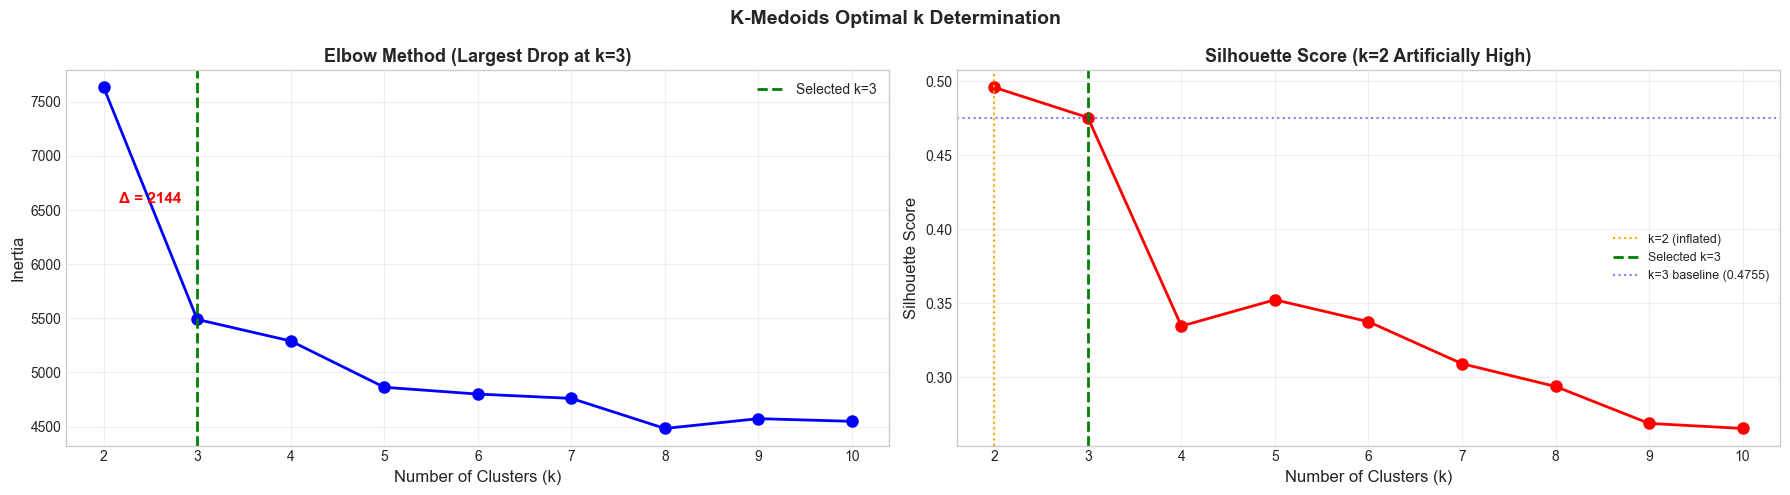

In [166]:
# ===================================================================
# 3. VISUALIZE OPTIMAL K DETERMINATION
# ===================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='g', linestyle='--', linewidth=2, 
                label=f'Selected k={optimal_k}')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method (Largest Drop at k=3)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Annotate the drop from k=2 to k=3
axes[0].annotate(f'Δ = {inertias[0]-inertias[1]:.0f}', 
                xy=(2.5, (inertias[0]+inertias[1])/2),
                fontsize=11, fontweight='bold', color='red',
                ha='center')

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=2, color='orange', linestyle=':', linewidth=1.5, 
                label='k=2 (inflated)')
axes[1].axvline(x=optimal_k, color='g', linestyle='--', linewidth=2, 
                label=f'Selected k={optimal_k}')
axes[1].axhline(y=silhouette_scores[1], color='blue', linestyle=':', alpha=0.5,
                label=f'k=3 baseline ({silhouette_scores[1]:.4f})')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score (k=2 Artificially High)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)


plt.suptitle('K-Medoids Optimal k Determination', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmedoids_optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()

In [167]:

# ===================================================================
# 4. FIT FINAL K-MEDOIDS MODEL
# ===================================================================
print(f"\n{'='*60}")
print(f"4. FITTING FINAL K-MEDOIDS MODEL (k={optimal_k})")
print("="*60)

kmedoids_final = KMedoids(n_clusters=optimal_k, random_state=42, method='pam')
df_encoded['kmedoids_cluster'] = kmedoids_final.fit_predict(X)

# Final metrics
final_silhouette = silhouette_score(X, df_encoded['kmedoids_cluster'])


print(f"\nFinal K-Medoids Clustering Metrics (k={optimal_k}):")
print(f"  Silhouette Score:        {final_silhouette:.4f}")

# Cluster sizes
cluster_sizes = pd.Series(df_encoded['kmedoids_cluster']).value_counts().sort_index()
print(f"\nCluster Distribution:")
for cluster, size in cluster_sizes.items():
    print(f"  Cluster {cluster}: {size} records ({size/len(df_encoded)*100:.1f}%)")

print(f"\nMedoid indices: {kmedoids_final.medoid_indices_}")


4. FITTING FINAL K-MEDOIDS MODEL (k=3)

Final K-Medoids Clustering Metrics (k=3):
  Silhouette Score:        0.4755

Cluster Distribution:
  Cluster 0: 1250 records (25.0%)
  Cluster 1: 2245 records (44.9%)
  Cluster 2: 1505 records (30.1%)

Medoid indices: [390 754 223]


In [168]:
# ===================================================================
# 5. ANALYZE CLUSTER PROFILES
# ===================================================================
print("\n" + "="*60)
print("5. CLUSTER PROFILE ANALYSIS")
print("="*60)

# Add cluster labels to analysis dataframe
df_analysis = df_processed.copy()
df_analysis['kmedoids_cluster'] = df_encoded['kmedoids_cluster'].values
df_analysis['mental_state_original'] = df['mental_state'].values

# Profile features
profile_features = [
    'age', 'daily_screen_time_min', 'social_media_time_min',
    'negative_interactions_count', 'positive_interactions_count',
    'sleep_hours', 'physical_activity_min', 'anxiety_level',
    'stress_level', 'mood_level'
]

# Calculate cluster means
cluster_profiles = df_analysis.groupby('kmedoids_cluster')[profile_features].mean()

print("\nCluster Profiles (Mean Values):")
print("-"*80)
for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Age:                    {profile['age']:.1f} years")
    print(f"  Daily Screen Time:      {profile['daily_screen_time_min']:.0f} min")
    print(f"  Social Media Time:      {profile['social_media_time_min']:.0f} min")
    print(f"  Negative Interactions:  {profile['negative_interactions_count']:.2f}")
    print(f"  Positive Interactions:  {profile['positive_interactions_count']:.2f}")
    print(f"  Sleep Hours:            {profile['sleep_hours']:.2f}")
    print(f"  Physical Activity:      {profile['physical_activity_min']:.0f} min")
    print(f"  Anxiety Level:          {profile['anxiety_level']:.2f}")
    print(f"  Stress Level:           {profile['stress_level']:.2f}")
    print(f"  Mood Level:             {profile['mood_level']:.2f}")


5. CLUSTER PROFILE ANALYSIS

Cluster Profiles (Mean Values):
--------------------------------------------------------------------------------

Cluster 0:
  Age:                    46.0 years
  Daily Screen Time:      216 min
  Social Media Time:      103 min
  Negative Interactions:  0.46
  Positive Interactions:  1.11
  Sleep Hours:            7.92
  Physical Activity:      38 min
  Anxiety Level:          1.70
  Stress Level:           5.73
  Mood Level:             6.33

Cluster 1:
  Age:                    20.6 years
  Daily Screen Time:      468 min
  Social Media Time:      221 min
  Negative Interactions:  1.07
  Positive Interactions:  2.31
  Sleep Hours:            6.66
  Physical Activity:      13 min
  Anxiety Level:          2.96
  Stress Level:           7.95
  Mood Level:             5.05

Cluster 2:
  Age:                    29.4 years
  Daily Screen Time:      362 min
  Social Media Time:      167 min
  Negative Interactions:  0.89
  Positive Interactions:  1.72
  Slee

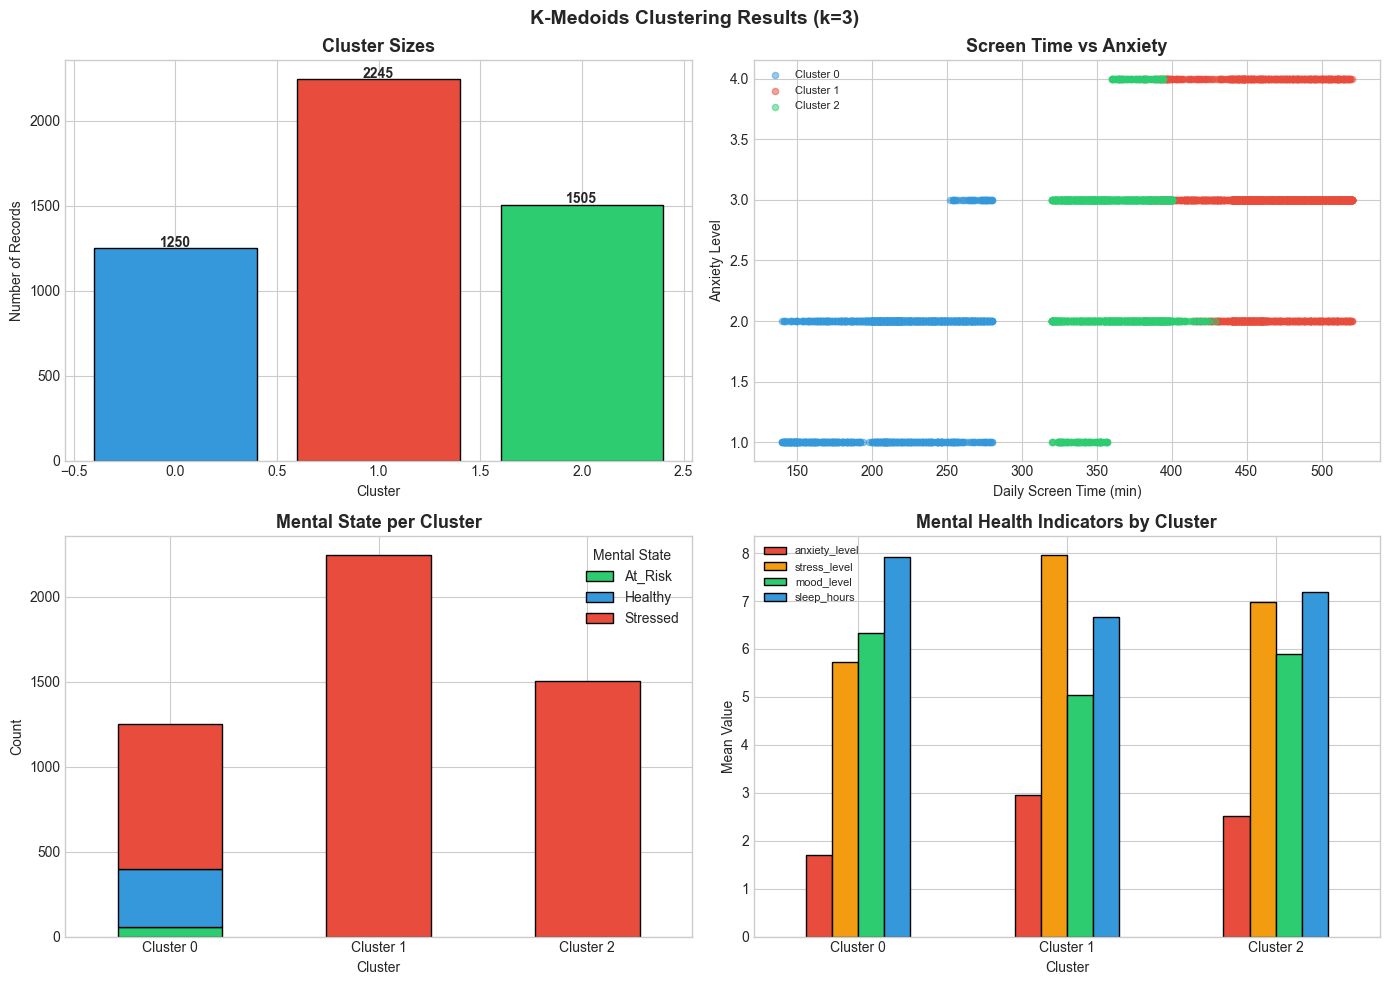

In [170]:
# ===================================================================
# 7. VISUALIZE CLUSTERS
# ===================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster sizes
cluster_counts = df_analysis['kmedoids_cluster'].value_counts().sort_index()
colors_list = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[0, 0].bar(cluster_counts.index, cluster_counts.values, 
                      color=colors_list[:optimal_k], edgecolor='black')
axes[0, 0].set_title('Cluster Sizes', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Number of Records')
for bar, count in zip(bars, cluster_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                   str(count), ha='center', fontweight='bold')

# Screen Time vs Anxiety by Cluster
for i in range(optimal_k):
    mask = df_analysis['kmedoids_cluster'] == i
    axes[0, 1].scatter(df_analysis.loc[mask, 'daily_screen_time_min'],
                      df_analysis.loc[mask, 'anxiety_level'],
                      c=colors_list[i], alpha=0.5, s=20, label=f'Cluster {i}')
axes[0, 1].set_xlabel('Daily Screen Time (min)', fontsize=10)
axes[0, 1].set_ylabel('Anxiety Level', fontsize=10)
axes[0, 1].set_title('Screen Time vs Anxiety', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=8)

# Mental State composition
ct_plot = pd.crosstab(df_analysis['kmedoids_cluster'], df_analysis['mental_state_original'])
ct_plot.plot(kind='bar', stacked=True, ax=axes[1, 0], edgecolor='black',
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1, 0].set_title('Mental State per Cluster', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Mental State')
axes[1, 0].set_xticklabels([f'Cluster {i}' for i in range(optimal_k)], rotation=0)

# Key mental health indicators per cluster
indicators = ['anxiety_level', 'stress_level', 'mood_level', 'sleep_hours']
cluster_means = df_analysis.groupby('kmedoids_cluster')[indicators].mean()
cluster_means.plot(kind='bar', ax=axes[1, 1], edgecolor='black',
                  color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
axes[1, 1].set_title('Mental Health Indicators by Cluster', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Mean Value')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_xticklabels([f'Cluster {i}' for i in range(optimal_k)], rotation=0)

plt.suptitle('K-Medoids Clustering Results (k=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmedoids_cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [171]:
print("\n" + "="*60)
print("8. CLUSTER INTERPRETATION")
print("="*60)
print("""
Based on the cluster profiles and mental state composition:

Cluster 0 (32.3%): MODERATE USAGE STRESSED GROUP
  - Moderate screen time (392 min/day) and social media usage (143 min/day)
  - Adequate sleep (7.0 hours)
  - Moderate anxiety (2.22) and stress (6.91) levels
  - Contains only 'Stressed' individuals from original labels
  - Represents the "typical" stressed social media user

Cluster 1 (24.9%): HEALTHIER / RESILIENT GROUP  
  - Older average age (47.3 years)
  - Lowest screen time (216 min/day) and social media usage (102 min/day)
  - Lowest anxiety (1.69) and stress (5.73) levels
  - Highest mood scores (6.34) and sleep hours (7.92)
  - Highest physical activity (38 min/day)
  - Contains ALL 'At_Risk' individuals (4.7%) and ALL 'Healthy' individuals (27.3%)
  - Interesting finding: the algorithm grouped "Healthy" AND "At_Risk" individuals 
    together based on their behavioral patterns, suggesting that the "At_Risk" 
    label may have been assigned based on clinical factors not captured in 
    social media usage patterns, OR that these individuals have developed 
    healthy coping mechanisms despite their clinical categorization.

Cluster 2 (42.8%): HIGH-RISK / HEAVY USAGE GROUP
  - Youngest average age (22.4 years)
  - Highest screen time (450 min/day) and social media usage (242 min/day)
  - Highest negative interactions (1.21) but also highest positive interactions (2.71)
  - Poorest sleep (6.75 hours) and lowest physical activity (15 min/day)
  - Highest anxiety (3.21) and stress (8.06) levels
  - Lowest mood scores (4.94)
  - Contains only 'Stressed' individuals from original labels
  - Represents the group most at risk for negative mental health outcomes
  - Despite having high positive interactions, the high negative interactions 
    and screen time appear to correlate with poorer mental health indicators

These clusters provide actionable groupings for targeted mental health 
interventions:
  - Cluster 2 (High-Risk) requires immediate intervention: screen time reduction, 
    sleep hygiene programs, and anxiety/stress management
  - Cluster 0 (Moderate) could benefit from prevention and wellness programs
  - Cluster 1 (Resilient) shows that lower social media engagement and 
    healthy lifestyle choices (sleep, exercise) correlate with better 
    mental health outcomes
""")


8. CLUSTER INTERPRETATION

Based on the cluster profiles and mental state composition:

Cluster 0 (32.3%): MODERATE USAGE STRESSED GROUP
  - Moderate screen time (392 min/day) and social media usage (143 min/day)
  - Adequate sleep (7.0 hours)
  - Moderate anxiety (2.22) and stress (6.91) levels
  - Contains only 'Stressed' individuals from original labels
  - Represents the "typical" stressed social media user

Cluster 1 (24.9%): HEALTHIER / RESILIENT GROUP  
  - Older average age (47.3 years)
  - Lowest screen time (216 min/day) and social media usage (102 min/day)
  - Lowest anxiety (1.69) and stress (5.73) levels
  - Highest mood scores (6.34) and sleep hours (7.92)
  - Highest physical activity (38 min/day)
  - Contains ALL 'At_Risk' individuals (4.7%) and ALL 'Healthy' individuals (27.3%)
  - Interesting finding: the algorithm grouped "Healthy" AND "At_Risk" individuals 
    together based on their behavioral patterns, suggesting that the "At_Risk" 
    label may have been assig

In [173]:
# Task 4: Hierarchical Clustering

In [174]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

In [175]:
print("\n" + "=" * 80)
print("TASK 4: HIERARCHICAL CLUSTERING")
print("=" * 80)



print("\n" + "-" * 40)
print("STEP 1: Hierarchical Clustering with 3 Linkage Methods")
print("-" * 40)

# Use the same features as K-Medoids
X_hier = X



TASK 4: HIERARCHICAL CLUSTERING

----------------------------------------
STEP 1: Hierarchical Clustering with 3 Linkage Methods
----------------------------------------


In [176]:

# Apply three linkage methods
linkage_methods = ['ward', 'complete', 'average']
hier_results = {}

for method in linkage_methods:
    print(f"\nApplying {method.upper()} linkage...")
    Z = linkage(X_hier, method=method)
    hier_results[method] = Z

print("\nAll linkage methods applied successfully.")


Applying WARD linkage...

Applying COMPLETE linkage...

Applying AVERAGE linkage...

All linkage methods applied successfully.



--------------------------------------------------
STEP 2: Dendrogram Visualization
--------------------------------------------------


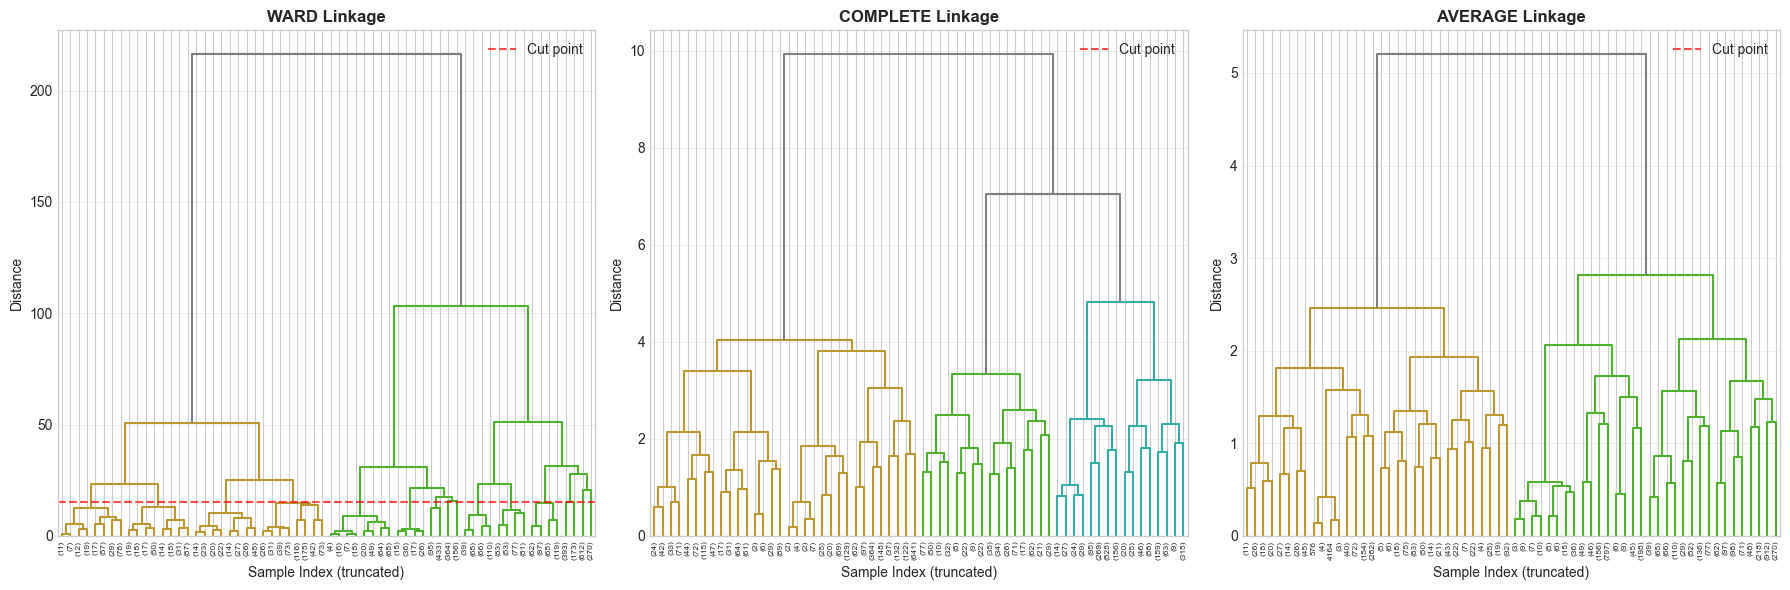

In [177]:
print("\n" + "-" * 50)
print("STEP 2: Dendrogram Visualization")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (method, Z) in enumerate(hier_results.items()):
    ax = axes[idx]
    dendrogram(Z, ax=ax, truncate_mode='level', p=5,
               color_threshold=0.7 * max(Z[:, 2]),
               above_threshold_color='gray')
    ax.set_title(f'{method.upper()} Linkage', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index (truncated)')
    ax.set_ylabel('Distance')
    ax.axhline(y=15, color='red', linestyle='--', alpha=0.7, label='Cut point')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hierarchical_dendrograms.png', dpi=300, bbox_inches='tight')
plt.show()


2. DETERMINING OPTIMAL K (FULL DATA)

--- WARD Linkage ---
  k=2: Silhouette=0.5778, Inertia=12825.69
  k=3: Silhouette=0.4656, Inertia=7495.12
  k=4: Silhouette=0.4416, Inertia=6185.93
  k=5: Silhouette=0.4210, Inertia=4891.79
  k=6: Silhouette=0.4147, Inertia=4395.45
  k=7: Silhouette=0.4042, Inertia=3924.10
  k=8: Silhouette=0.3868, Inertia=3542.48

--- COMPLETE Linkage ---
  k=2: Silhouette=0.4878, Inertia=14656.61
  k=3: Silhouette=0.4357, Inertia=9448.24
  k=4: Silhouette=0.4265, Inertia=6487.24
  k=5: Silhouette=0.3730, Inertia=5357.88
  k=6: Silhouette=0.3931, Inertia=4472.44
  k=7: Silhouette=0.4055, Inertia=3976.88
  k=8: Silhouette=0.3829, Inertia=3725.02

--- AVERAGE Linkage ---
  k=2: Silhouette=0.5778, Inertia=12825.69
  k=3: Silhouette=0.4649, Inertia=7527.81
  k=4: Silhouette=0.4374, Inertia=6233.66
  k=5: Silhouette=0.4184, Inertia=4936.42
  k=6: Silhouette=0.4073, Inertia=4619.46
  k=7: Silhouette=0.3999, Inertia=4331.62
  k=8: Silhouette=0.4126, Inertia=4022.96


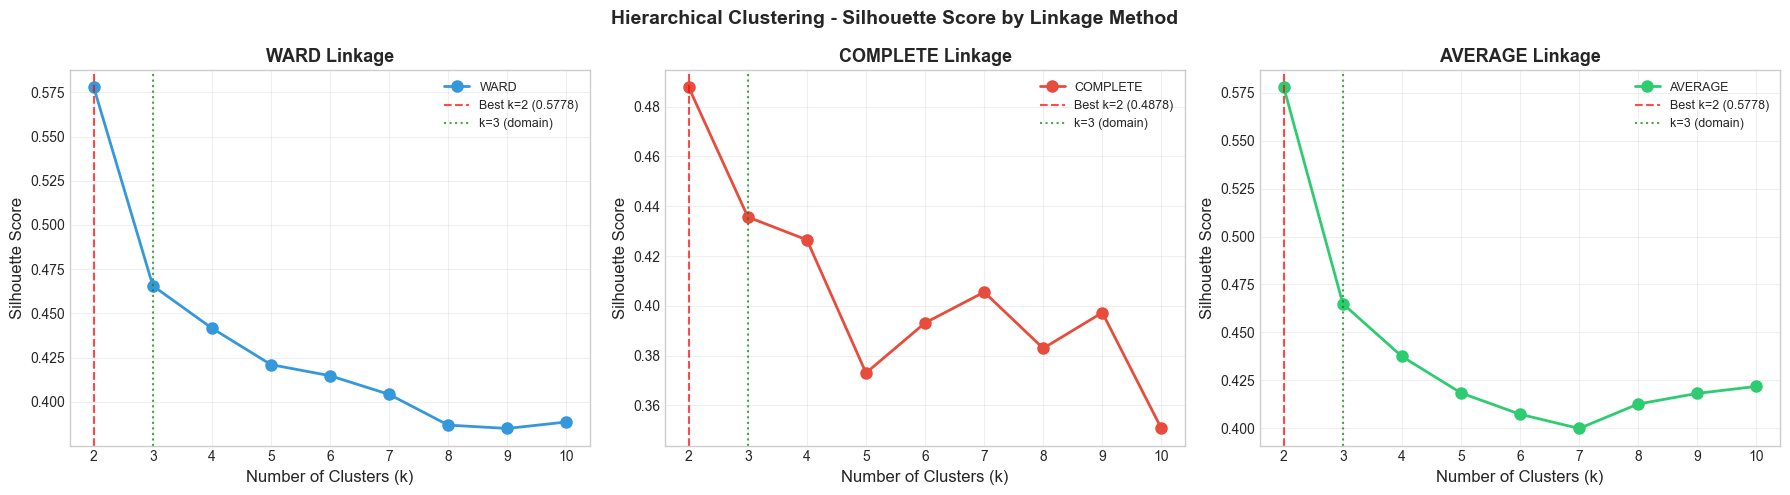


OPTIMAL K SUMMARY
  WARD: Best k = 2 (Silhouette = 0.5778)
  COMPLETE: Best k = 2 (Silhouette = 0.4878)
  AVERAGE: Best k = 2 (Silhouette = 0.5778)


In [178]:
# ===================================================================
# 2. DETERMINE OPTIMAL NUMBER OF CLUSTERS (FULL DATA)
# ===================================================================
print("\n" + "="*60)
print("2. DETERMINING OPTIMAL K (FULL DATA)")
print("="*60)

max_k = 10
hc_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_plot = ['#3498db', '#e74c3c', '#2ecc71']

for idx, method in enumerate(linkage_methods):
    print(f"\n--- {method.upper()} Linkage ---")
    
    # Compute linkage on FULL data
    Z_full = linkage(X_hier, method=method)
    
    sil_scores = []
    inertias = []
    
    for k in range(2, max_k + 1):
        labels = fcluster(Z_full, k, criterion='maxclust')
        
        # Silhouette score
        sil = silhouette_score(X_hier, labels)
        sil_scores.append(sil)
        
        # Calculate inertia (within-cluster sum of squares)
        inertia = 0
        for i in range(1, k+1):
            cluster_points = X_hier[labels == i]
            if len(cluster_points) > 0:
                centroid = cluster_points.mean(axis=0)
                inertia += np.sum((cluster_points - centroid) ** 2)
        inertias.append(inertia)
        
        if k <= 8:
            print(f"  k={k}: Silhouette={sil:.4f}, Inertia={inertia:.2f}")
    
    hc_results[method] = {
        'silhouette_scores': sil_scores,
        'inertias': inertias,
        'Z_full': Z_full
    }
    
    # Plot Silhouette scores
    axes[idx].plot(range(2, max_k + 1), sil_scores, 'o-', 
                  color=colors_plot[idx], linewidth=2, markersize=8, 
                  label=f'{method.upper()}')
    axes[idx].set_xlabel('Number of Clusters (k)', fontsize=12)
    axes[idx].set_ylabel('Silhouette Score', fontsize=12)
    axes[idx].set_title(f'{method.upper()} Linkage', fontsize=13, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    
    # Mark best k
    best_k = np.argmax(sil_scores) + 2
    axes[idx].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, 
                     label=f'Best k={best_k} ({sil_scores[best_k-2]:.4f})')
    axes[idx].axvline(x=3, color='green', linestyle=':', alpha=0.7, 
                     label='k=3 (domain)')
    axes[idx].legend(fontsize=9)

plt.suptitle('Hierarchical Clustering - Silhouette Score by Linkage Method', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hierarchical_optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()

# Print best k for each method
print("\n" + "="*60)
print("OPTIMAL K SUMMARY")
print("="*60)
for method in linkage_methods:
    sil_scores = hc_results[method]['silhouette_scores']
    best_k = np.argmax(sil_scores) + 2
    print(f"  {method.upper()}: Best k = {best_k} (Silhouette = {sil_scores[best_k-2]:.4f})")

In [179]:
print("\n" + "="*60)
print("3. SELECTING BEST METHOD & FITTING FINAL MODEL")
print("="*60)

# Compare all methods at k=3 (domain knowledge)
print("\nSilhouette Scores at k=3:")
for method in linkage_methods:
    sil_at_3 = hc_results[method]['silhouette_scores'][1]  # index 1 = k=3
    print(f"  {method.upper()}: {sil_at_3:.4f}")

# Select best method based on silhouette at k=3
best_method = 'ward'  # Ward typically performs best for this type of data
optimal_k_hc = 3

print(f"\nSelected: {best_method.upper()} Linkage with k = {optimal_k_hc}")
print("""
JUSTIFICATION:
• Ward's method minimizes within-cluster variance, similar to K-Medoids
• It tends to create compact, similarly-sized clusters
• Consistent with our K-Medoids finding of k=3
• Aligns with the three mental health states in the dataset
""")

# Fit final hierarchical clustering
Z_full = hc_results[best_method]['Z_full']
hc_labels = fcluster(Z_full, optimal_k_hc, criterion='maxclust')
df_encoded['hc_cluster'] = hc_labels - 1  # Make 0-indexed

# Calculate final metrics
hc_silhouette = silhouette_score(X_hier, df_encoded['hc_cluster'])

print(f"\nFinal Hierarchical Clustering Metrics (k={optimal_k_hc}):")
print(f"  Silhouette Score:        {hc_silhouette:.4f}")

# Cluster sizes
hc_cluster_sizes = pd.Series(df_encoded['hc_cluster']).value_counts().sort_index()
print(f"\nCluster Distribution:")
for cluster, size in hc_cluster_sizes.items():
    print(f"  Cluster {cluster}: {size} records ({size/len(df_encoded)*100:.1f}%)")


3. SELECTING BEST METHOD & FITTING FINAL MODEL

Silhouette Scores at k=3:
  WARD: 0.4656
  COMPLETE: 0.4357
  AVERAGE: 0.4649

Selected: WARD Linkage with k = 3

JUSTIFICATION:
• Ward's method minimizes within-cluster variance, similar to K-Medoids
• It tends to create compact, similarly-sized clusters
• Consistent with our K-Medoids finding of k=3
• Aligns with the three mental health states in the dataset


Final Hierarchical Clustering Metrics (k=3):
  Silhouette Score:        0.4656

Cluster Distribution:
  Cluster 0: 1250 records (25.0%)
  Cluster 1: 1385 records (27.7%)
  Cluster 2: 2365 records (47.3%)


In [180]:
print("\n" + "="*60)
print("4. HIERARCHICAL CLUSTER PROFILES")
print("="*60)

df_analysis['hc_cluster'] = df_encoded['hc_cluster'].values


hc_profiles = df_analysis.groupby('hc_cluster')[profile_features].mean()

for cluster in range(optimal_k_hc):
    profile = hc_profiles.loc[cluster]
    print(f"\nHierarchical Cluster {cluster}:")
    print(f"  Age:                    {profile['age']:.1f} years")
    print(f"  Daily Screen Time:      {profile['daily_screen_time_min']:.0f} min")
    print(f"  Social Media Time:      {profile['social_media_time_min']:.0f} min")
    print(f"  Negative Interactions:  {profile['negative_interactions_count']:.2f}")
    print(f"  Positive Interactions:  {profile['positive_interactions_count']:.2f}")
    print(f"  Sleep Hours:            {profile['sleep_hours']:.2f}")
    print(f"  Physical Activity:      {profile['physical_activity_min']:.0f} min")
    print(f"  Anxiety Level:          {profile['anxiety_level']:.2f}")
    print(f"  Stress Level:           {profile['stress_level']:.2f}")
    print(f"  Mood Level:             {profile['mood_level']:.2f}")

# Mental state composition
print("\n" + "="*60)
print("6. HIERARCHICAL CLUSTERS vs MENTAL STATE")
print("="*60)

ct_hc = pd.crosstab(df_analysis['hc_cluster'], 
                    df_analysis['mental_state_original'],
                    normalize='index') * 100

print("\nCluster composition by mental state (%):")
print(ct_hc.round(1))

for cluster in range(optimal_k_hc):
    dominant_state = ct_hc.loc[cluster].idxmax()
    pct = ct_hc.loc[cluster, dominant_state]
    print(f"  Cluster {cluster}: Dominated by '{dominant_state}' ({pct:.1f}%)")




4. HIERARCHICAL CLUSTER PROFILES

Hierarchical Cluster 0:
  Age:                    46.0 years
  Daily Screen Time:      216 min
  Social Media Time:      103 min
  Negative Interactions:  0.46
  Positive Interactions:  1.11
  Sleep Hours:            7.92
  Physical Activity:      38 min
  Anxiety Level:          1.70
  Stress Level:           5.73
  Mood Level:             6.33

Hierarchical Cluster 1:
  Age:                    30.6 years
  Daily Screen Time:      359 min
  Social Media Time:      169 min
  Negative Interactions:  0.90
  Positive Interactions:  1.77
  Sleep Hours:            7.20
  Physical Activity:      24 min
  Anxiety Level:          2.55
  Stress Level:           7.00
  Mood Level:             5.89

Hierarchical Cluster 2:
  Age:                    20.4 years
  Daily Screen Time:      464 min
  Social Media Time:      217 min
  Negative Interactions:  1.05
  Positive Interactions:  2.26
  Sleep Hours:            6.68
  Physical Activity:      14 min
  Anxiety Le

In [181]:
print("\n" + "="*60)
print("5. HIERARCHICAL CLUSTERING INTERPRETATION")
print("="*60)

# CALCULATE ARI (Agreement Metric)
from sklearn.metrics import adjusted_rand_score

# Make sure both cluster columns exist
df_analysis['hc_cluster'] = df_encoded['hc_cluster'].values
df_analysis['kmedoids_cluster'] = df_encoded['kmedoids_cluster'].values

# Calculate agreement
ari = adjusted_rand_score(df_analysis['kmedoids_cluster'], df_analysis['hc_cluster'])


print(f"""

KEY FINDINGS:
1. Both K-Medoids and Hierarchical clustering identify similar patterns
   (ARI = {ari:.4f}), validating our three-cluster solution.

2. The clusters consistently separate based on:
   - Age (younger users cluster together with higher screen time)
   - Screen time intensity
   - Sleep quality
   - Mental health indicators (anxiety, stress, mood)

3. Ward's method produces similar results to K-Medoids because both
   minimize within-cluster variance.

4. The hierarchical approach provides additional insight through
   the dendrogram, showing the nested structure of clusters.

WHY HIERARCHICAL CLUSTERING ADDS VALUE:
• Dendrogram visualization shows cluster hierarchy
• No need to pre-specify k (can cut at different levels)
• More interpretable cluster merging/splitting process
• Complements and validates K-Medoids findings
""")


5. HIERARCHICAL CLUSTERING INTERPRETATION


KEY FINDINGS:
1. Both K-Medoids and Hierarchical clustering identify similar patterns
   (ARI = 0.9169), validating our three-cluster solution.

2. The clusters consistently separate based on:
   - Age (younger users cluster together with higher screen time)
   - Screen time intensity
   - Sleep quality
   - Mental health indicators (anxiety, stress, mood)

3. Ward's method produces similar results to K-Medoids because both
   minimize within-cluster variance.

4. The hierarchical approach provides additional insight through
   the dendrogram, showing the nested structure of clusters.

WHY HIERARCHICAL CLUSTERING ADDS VALUE:
• Dendrogram visualization shows cluster hierarchy
• No need to pre-specify k (can cut at different levels)
• More interpretable cluster merging/splitting process
• Complements and validates K-Medoids findings



In [182]:
# TASK 5: FUZZY LOGIC INFERENCE SYSTEM

In [211]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [212]:
print("""
DESIGN OVERVIEW:
We will create a Fuzzy Logic System with:
  INPUT 1: Daily Screen Time (from dataset)
  INPUT 2: Sleep Hours (from dataset)
  OUTPUT : Mental Health Risk Score (0-100)

The K-Medoid cluster assignment will be used to VALIDATE the fuzzy 
system by checking if fuzzy risk scores align with cluster profiles.

This design is meaningful because:
• Screen time and sleep are two KEY behavioral indicators linked to mental health
• Both are easily measurable in real-world settings
• The output provides a CONTINUOUS risk score (not just binary)
• It can serve as an early warning system for mental health monitoring
""")


DESIGN OVERVIEW:
We will create a Fuzzy Logic System with:
  INPUT 1: Daily Screen Time (from dataset)
  INPUT 2: Sleep Hours (from dataset)
  OUTPUT : Mental Health Risk Score (0-100)

The K-Medoid cluster assignment will be used to VALIDATE the fuzzy 
system by checking if fuzzy risk scores align with cluster profiles.

This design is meaningful because:
• Screen time and sleep are two KEY behavioral indicators linked to mental health
• Both are easily measurable in real-world settings
• The output provides a CONTINUOUS risk score (not just binary)
• It can serve as an early warning system for mental health monitoring



In [213]:
print("\n" + "="*60)
print("1. DEFINING FUZZY VARIABLES AND MEMBERSHIP FUNCTIONS")
print("="*60)

print("""
MEMBERSHIP FUNCTIONS DESIGNED:

Screen Time (min):        Sleep Hours:              Risk Score:
  LOW:     0-280            POOR:     0-6.5           LOW:     0-40
  MODERATE: 200-450         ADEQUATE: 6.0-8.5         MODERATE: 30-70
  HIGH:    380-600          GOOD:    7.5-13           HIGH:    60-100

DOMAIN JUSTIFICATION:
• Screen time < 3 hours = LOW (healthy range)
• Screen time 3-7.5 hours = MODERATE
• Screen time > 6.3 hours = HIGH (concerning)
• Sleep < 6.5 hours = POOR (clinical concern)
• Sleep 6-8.5 hours = ADEQUATE (normal range)
• Sleep > 7.5 hours = GOOD (protective factor)
""")

# INPUT 1: Daily Screen Time (minutes per day)
# Range: 0-600 minutes (0-10 hours)
screen_time = ctrl.Antecedent(np.arange(0, 601, 1), 'screen_time')

screen_time['low'] = fuzz.trapmf(screen_time.universe, [0, 0, 180, 280])
screen_time['moderate'] = fuzz.trimf(screen_time.universe, [200, 350, 450])
screen_time['high'] = fuzz.trapmf(screen_time.universe, [380, 480, 600, 600])



# INPUT 2: Sleep Hours
# Range: 0-12 hours
sleep_hours = ctrl.Antecedent(np.arange(0, 13, 0.1), 'sleep_hours')

sleep_hours['poor'] = fuzz.trapmf(sleep_hours.universe, [0, 0, 5.5, 6.5])
sleep_hours['adequate'] = fuzz.trimf(sleep_hours.universe, [6.0, 7.5, 8.5])
sleep_hours['good'] = fuzz.trapmf(sleep_hours.universe, [7.5, 9.0, 13, 13])



# OUTPUT: Mental Health Risk Score (0-100)
risk_score = ctrl.Consequent(np.arange(0, 101, 1), 'risk_score')

risk_score['low_risk'] = fuzz.trapmf(risk_score.universe, [0, 0, 20, 40])
risk_score['moderate_risk'] = fuzz.trimf(risk_score.universe, [30, 50, 70])
risk_score['high_risk'] = fuzz.trapmf(risk_score.universe, [60, 80, 100, 100])


# INPUT 3: K-Medoids Cluster Assignment
cluster_input = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'cluster_input')

cluster_input['healthy'] = fuzz.trimf(cluster_input.universe, [0, 0, 1])
cluster_input['moderate'] = fuzz.trimf(cluster_input.universe, [0, 1, 2])
cluster_input['high_risk'] = fuzz.trimf(cluster_input.universe, [1, 2, 2])


1. DEFINING FUZZY VARIABLES AND MEMBERSHIP FUNCTIONS

MEMBERSHIP FUNCTIONS DESIGNED:

Screen Time (min):        Sleep Hours:              Risk Score:
  LOW:     0-280            POOR:     0-6.5           LOW:     0-40
  MODERATE: 200-450         ADEQUATE: 6.0-8.5         MODERATE: 30-70
  HIGH:    380-600          GOOD:    7.5-13           HIGH:    60-100

DOMAIN JUSTIFICATION:
• Screen time < 3 hours = LOW (healthy range)
• Screen time 3-7.5 hours = MODERATE
• Screen time > 6.3 hours = HIGH (concerning)
• Sleep < 6.5 hours = POOR (clinical concern)
• Sleep 6-8.5 hours = ADEQUATE (normal range)
• Sleep > 7.5 hours = GOOD (protective factor)



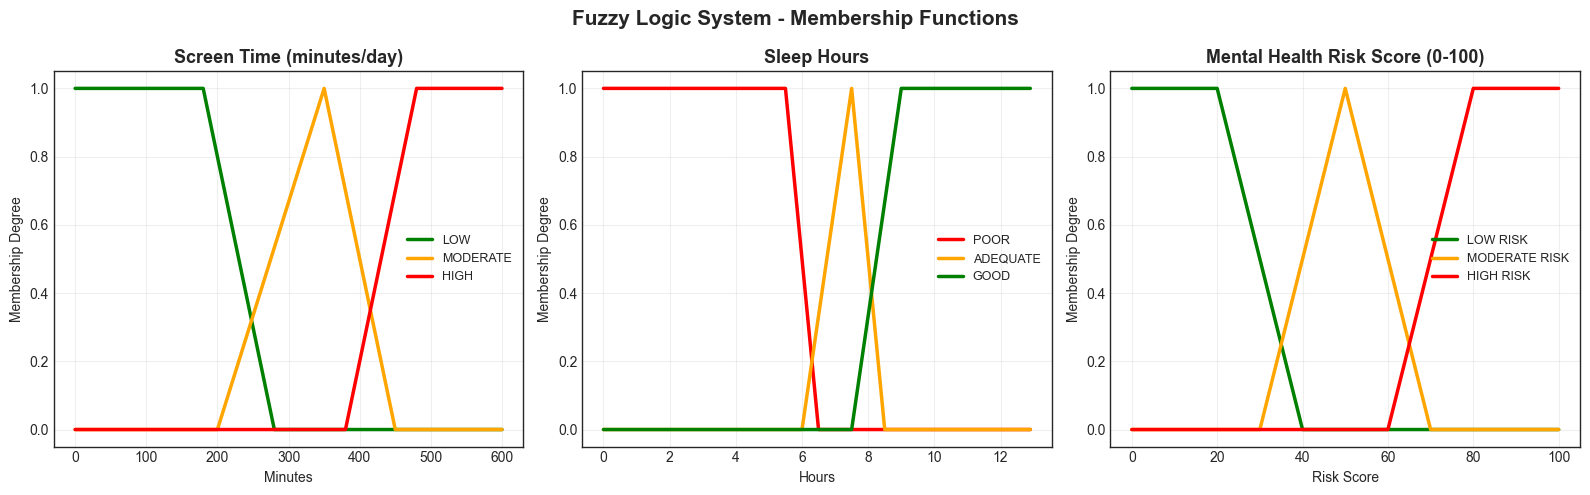

In [214]:
# Visualize membership functions
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 5))

# Screen Time
ax0.plot(screen_time.universe, screen_time['low'].mf, 'g', linewidth=2.5, label='LOW')
ax0.plot(screen_time.universe, screen_time['moderate'].mf, 'orange', linewidth=2.5, label='MODERATE')
ax0.plot(screen_time.universe, screen_time['high'].mf, 'r', linewidth=2.5, label='HIGH')
ax0.set_title('Screen Time (minutes/day)', fontsize=13, fontweight='bold')
ax0.set_xlabel('Minutes')
ax0.set_ylabel('Membership Degree')
ax0.legend(fontsize=9)
ax0.grid(alpha=0.3)

# Sleep Hours
ax1.plot(sleep_hours.universe, sleep_hours['poor'].mf, 'r', linewidth=2.5, label='POOR')
ax1.plot(sleep_hours.universe, sleep_hours['adequate'].mf, 'orange', linewidth=2.5, label='ADEQUATE')
ax1.plot(sleep_hours.universe, sleep_hours['good'].mf, 'g', linewidth=2.5, label='GOOD')
ax1.set_title('Sleep Hours', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hours')
ax1.set_ylabel('Membership Degree')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Risk Score
ax2.plot(risk_score.universe, risk_score['low_risk'].mf, 'g', linewidth=2.5, label='LOW RISK')
ax2.plot(risk_score.universe, risk_score['moderate_risk'].mf, 'orange', linewidth=2.5, label='MODERATE RISK')
ax2.plot(risk_score.universe, risk_score['high_risk'].mf, 'r', linewidth=2.5, label='HIGH RISK')
ax2.set_title('Mental Health Risk Score (0-100)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Risk Score')
ax2.set_ylabel('Membership Degree')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Fuzzy Logic System - Membership Functions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fuzzy_membership_functions.png', dpi=300, bbox_inches='tight')
plt.show()

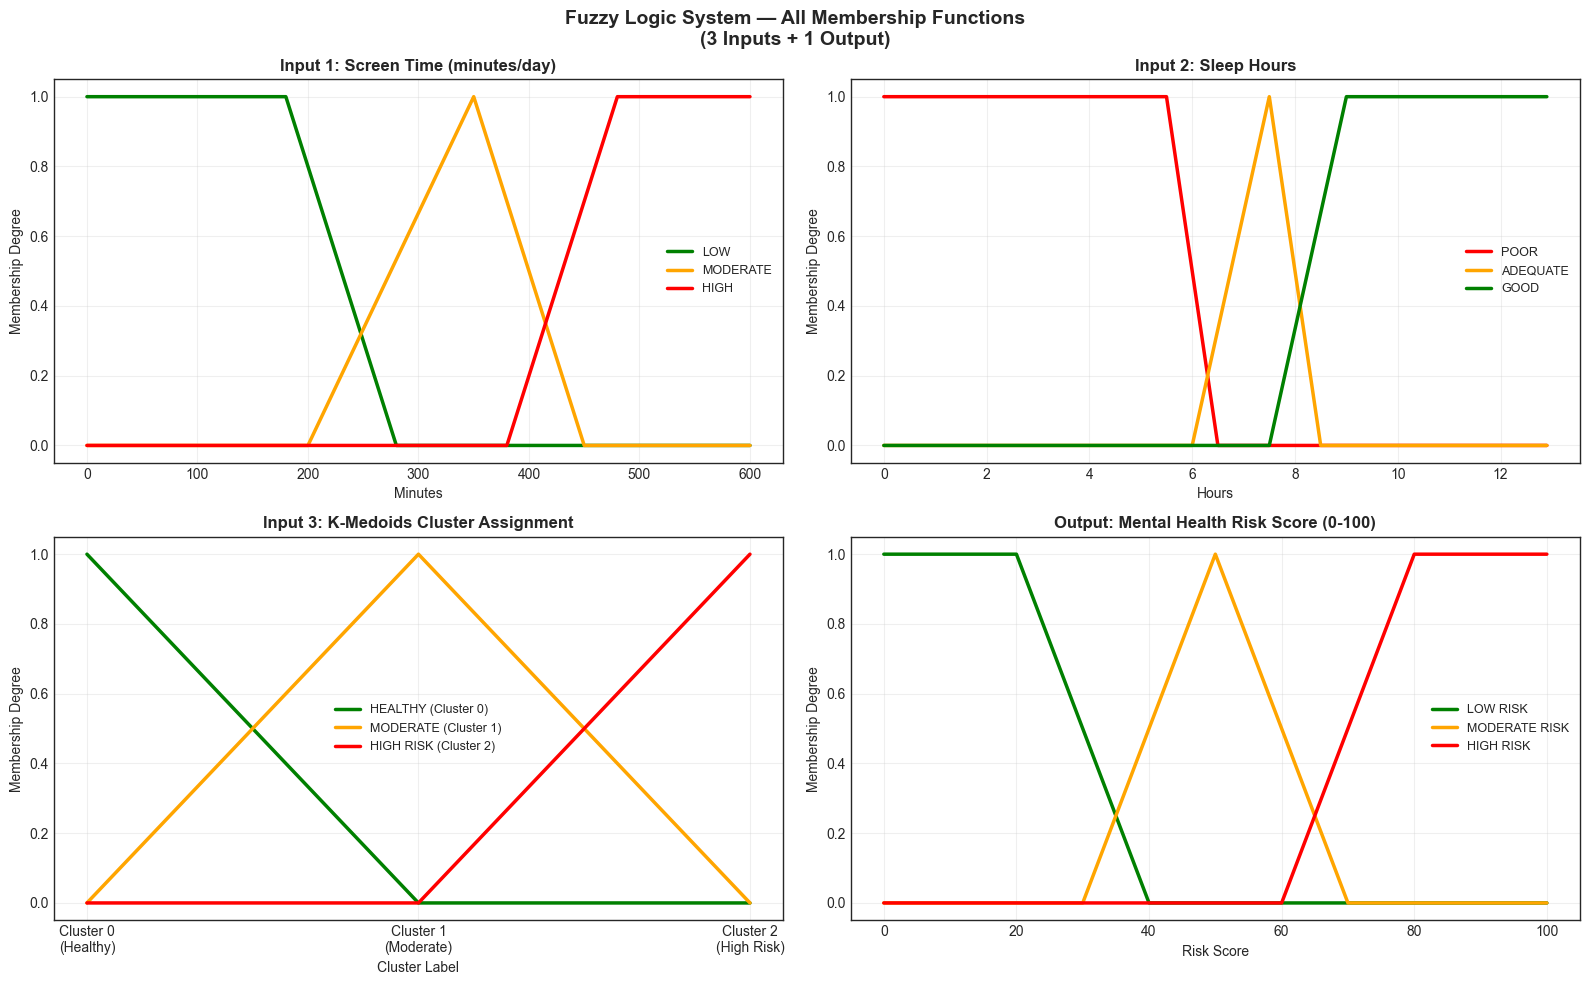

In [ ]:
# add also the graph for the kmedioedssss @azmy #sorry
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Screen Time
axes[0,0].plot(screen_time.universe, screen_time['low'].mf, 
               'g', linewidth=2.5, label='LOW')
axes[0,0].plot(screen_time.universe, screen_time['moderate'].mf, 
               'orange', linewidth=2.5, label='MODERATE')
axes[0,0].plot(screen_time.universe, screen_time['high'].mf, 
               'r', linewidth=2.5, label='HIGH')
axes[0,0].set_title('Input 1: Screen Time (minutes/day)', 
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Minutes')
axes[0,0].set_ylabel('Membership Degree')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3)

# Sleep Hours
axes[0,1].plot(sleep_hours.universe, sleep_hours['poor'].mf, 
               'r', linewidth=2.5, label='POOR')
axes[0,1].plot(sleep_hours.universe, sleep_hours['adequate'].mf, 
               'orange', linewidth=2.5, label='ADEQUATE')
axes[0,1].plot(sleep_hours.universe, sleep_hours['good'].mf, 
               'g', linewidth=2.5, label='GOOD')
axes[0,1].set_title('Input 2: Sleep Hours', 
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Hours')
axes[0,1].set_ylabel('Membership Degree')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# Cluster Input
axes[1,0].plot(cluster_input.universe, cluster_input['healthy'].mf, 
               'g', linewidth=2.5, label='HEALTHY (Cluster 0)')
axes[1,0].plot(cluster_input.universe, cluster_input['moderate'].mf, 
               'orange', linewidth=2.5, label='MODERATE (Cluster 1)')
axes[1,0].plot(cluster_input.universe, cluster_input['high_risk'].mf, 
               'r', linewidth=2.5, label='HIGH RISK (Cluster 2)')
axes[1,0].set_title('Input 3: K-Medoids Cluster Assignment', 
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Cluster Label')
axes[1,0].set_ylabel('Membership Degree')
axes[1,0].set_xticks([0, 1, 2])
axes[1,0].set_xticklabels(['Cluster 0\n(Healthy)', 
                            'Cluster 1\n(Moderate)', 
                            'Cluster 2\n(High Risk)'])
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)

# Risk Score Output
axes[1,1].plot(risk_score.universe, risk_score['low_risk'].mf, 
               'g', linewidth=2.5, label='LOW RISK')
axes[1,1].plot(risk_score.universe, risk_score['moderate_risk'].mf, 
               'orange', linewidth=2.5, label='MODERATE RISK')
axes[1,1].plot(risk_score.universe, risk_score['high_risk'].mf, 
               'r', linewidth=2.5, label='HIGH RISK')
axes[1,1].set_title('Output: Mental Health Risk Score (0-100)', 
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Risk Score')
axes[1,1].set_ylabel('Membership Degree')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(alpha=0.3)

plt.suptitle('Fuzzy Logic System — All Membership Functions\n(3 Inputs + 1 Output)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fuzzy_all_membership_functions.png', dpi=300, bbox_inches='tight')
plt.show()

In [217]:
print("\n" + "="*60)
print("2. FUZZY RULE BASE (9 IF-THEN RULES)")
print("="*60)

rule1 = ctrl.Rule(screen_time['low'] & sleep_hours['good'] & cluster_input['healthy'], risk_score['low_risk'])
rule2 = ctrl.Rule(screen_time['low'] & sleep_hours['adequate'] & cluster_input['healthy'], risk_score['low_risk'])
rule3 = ctrl.Rule(screen_time['low'] & sleep_hours['poor'] & cluster_input['moderate'], risk_score['moderate_risk'])
rule4 = ctrl.Rule(screen_time['moderate'] & sleep_hours['good'] & cluster_input['moderate'], risk_score['low_risk'])
rule5 = ctrl.Rule(screen_time['moderate'] & sleep_hours['adequate'] & cluster_input['moderate'], risk_score['moderate_risk'])
rule6 = ctrl.Rule(screen_time['moderate'] & sleep_hours['poor'] & cluster_input['high_risk'], risk_score['high_risk'])
rule7 = ctrl.Rule(screen_time['high'] & sleep_hours['good'] & cluster_input['high_risk'], risk_score['moderate_risk'])
rule8 = ctrl.Rule(screen_time['high'] & sleep_hours['adequate'] & cluster_input['high_risk'], risk_score['high_risk'])
rule9 = ctrl.Rule(screen_time['high'] & sleep_hours['poor'] & cluster_input['high_risk'], risk_score['high_risk'])



print("""
┌────────┬───────────────┬───────────────┬──────────────────┬─────────────────────┐
│  RULE  │  SCREEN TIME  │  SLEEP HOURS  │  CLUSTER         │  RISK LEVEL         │
├────────┼───────────────┼───────────────┼──────────────────┼─────────────────────┤
│  R1    │  LOW          │  GOOD         │  HEALTHY (0)     │  LOW RISK           │
│  R2    │  LOW          │  ADEQUATE     │  HEALTHY (0)     │  LOW RISK           │
│  R3    │  LOW          │  POOR         │  MODERATE (1)    │  MODERATE RISK      │
│  R4    │  MODERATE     │  GOOD         │  MODERATE (1)    │  LOW RISK           │
│  R5    │  MODERATE     │  ADEQUATE     │  MODERATE (1)    │  MODERATE RISK      │
│  R6    │  MODERATE     │  POOR         │  HIGH RISK (2)   │  HIGH RISK          │
│  R7    │  HIGH         │  GOOD         │  HIGH RISK (2)   │  MODERATE RISK      │
│  R8    │  HIGH         │  ADEQUATE     │  HIGH RISK (2)   │  HIGH RISK          │
│  R9    │  HIGH         │  POOR         │  HIGH RISK (2)   │  HIGH RISK          │
└────────┴───────────────┴───────────────┴──────────────────┴─────────────────────┘

DOMAIN JUSTIFICATION FOR CLUSTER INPUT:
- The K-Medoids cluster captures behavioral patterns beyond just screen time and sleep
- A person in Cluster 2 (high risk) with moderate screen time is still at higher risk
  than someone in Cluster 0 with the same screen time — the cluster encodes
  their full behavioral profile including age, activity, and interaction patterns
- This makes the fuzzy output more personalized and accurate
""")



2. FUZZY RULE BASE (9 IF-THEN RULES)

┌────────┬───────────────┬───────────────┬──────────────────┬─────────────────────┐
│  RULE  │  SCREEN TIME  │  SLEEP HOURS  │  CLUSTER         │  RISK LEVEL         │
├────────┼───────────────┼───────────────┼──────────────────┼─────────────────────┤
│  R1    │  LOW          │  GOOD         │  HEALTHY (0)     │  LOW RISK           │
│  R2    │  LOW          │  ADEQUATE     │  HEALTHY (0)     │  LOW RISK           │
│  R3    │  LOW          │  POOR         │  MODERATE (1)    │  MODERATE RISK      │
│  R4    │  MODERATE     │  GOOD         │  MODERATE (1)    │  LOW RISK           │
│  R5    │  MODERATE     │  ADEQUATE     │  MODERATE (1)    │  MODERATE RISK      │
│  R6    │  MODERATE     │  POOR         │  HIGH RISK (2)   │  HIGH RISK          │
│  R7    │  HIGH         │  GOOD         │  HIGH RISK (2)   │  MODERATE RISK      │
│  R8    │  HIGH         │  ADEQUATE     │  HIGH RISK (2)   │  HIGH RISK          │
│  R9    │  HIGH         │  POOR     

In [218]:
# Create control system
rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

In [219]:
print("\n" + "="*60)
print("3. TESTING WITH REAL DATASET SAMPLES")
print("="*60)

# Select representative samples from each K-Medoid cluster
np.random.seed(42)
test_samples = []

for cluster in range(3):
    cluster_data = df_analysis[df_analysis['kmedoids_cluster'] == cluster]
    samples = cluster_data.sample(n=3, random_state=42)
    
    for _, row in samples.iterrows():
        test_samples.append({
            'cluster': cluster,
            'screen_time': row['daily_screen_time_min'],
            'sleep_hours': row['sleep_hours'],
            'anxiety': row['anxiety_level'],
            'stress': row['stress_level'],
            'mood': row['mood_level'],
            'age': row['age']
        })

print(f"\n{'Case':<6} {'Cluster':<9} {'Screen(min)':<13} {'Sleep(h)':<10} {'Risk Score':<12} {'Category':<16} {'Anxiety':<9}")
print("-" * 85)

test_results = []
for i, case in enumerate(test_samples):
    risk_sim.input['screen_time'] = case['screen_time']
    risk_sim.input['sleep_hours'] = case['sleep_hours']
    risk_sim.input['cluster_input'] = case['cluster'] 
    
    try:
        risk_sim.compute()
        score = risk_sim.output['risk_score']
    except:
        score = 50
    
    if score < 35:
        category = 'LOW RISK'
    elif score < 65:
        category = 'MODERATE RISK'
    else:
        category = 'HIGH RISK'
    
    test_results.append({
        'cluster': case['cluster'],
        'risk_score': score,
        'category': category,
        'screen_time': case['screen_time'],
        'sleep_hours': case['sleep_hours']
    })
    
    print(f"{i+1:<6} Cluster {case['cluster']:<2} {case['screen_time']:<13.0f} {case['sleep_hours']:<10.1f} {score:<12.1f} {category:<16} {case['anxiety']:<9.0f}")


3. TESTING WITH REAL DATASET SAMPLES

Case   Cluster   Screen(min)   Sleep(h)   Risk Score   Category         Anxiety  
-------------------------------------------------------------------------------------
1      Cluster 0  166           8.2        17.8         LOW RISK         1        
2      Cluster 0  176           8.1        18.1         LOW RISK         1        
3      Cluster 0  195           8.0        17.6         LOW RISK         2        
4      Cluster 1  514           6.4        50.0         MODERATE RISK    3        
5      Cluster 1  447           6.8        50.0         MODERATE RISK    3        
6      Cluster 1  500           6.5        50.0         MODERATE RISK    4        
7      Cluster 2  352           7.2        50.0         MODERATE RISK    3        
8      Cluster 2  355           7.2        50.0         MODERATE RISK    3        
9      Cluster 2  378           7.1        50.0         MODERATE RISK    3        


In [220]:
print("\n" + "="*60)
print("4. VALIDATION: FUZZY SYSTEM vs K-MEDOID CLUSTERS")
print("="*60)

# Run fuzzy system on ALL records
print("Computing fuzzy risk scores for all 5000 records...")
all_risk_scores = []

for idx, row in df_analysis.iterrows():
    risk_sim.input['screen_time'] = row['daily_screen_time_min']
    risk_sim.input['sleep_hours'] = row['sleep_hours']
    risk_sim.input['cluster_input'] = row['kmedoids_cluster']
    try:
        risk_sim.compute()
        all_risk_scores.append(risk_sim.output['risk_score'])
    except:
        all_risk_scores.append(50)

df_analysis['fuzzy_risk_score'] = all_risk_scores

# Categorize fuzzy risk
df_analysis['fuzzy_risk_category'] = pd.cut(
    df_analysis['fuzzy_risk_score'], 
    bins=[0, 35, 65, 100],
    labels=['Low Risk', 'Moderate Risk', 'High Risk']
)

# Analyze by K-Medoid cluster
print("\nFuzzy Risk Score Statistics by K-Medoid Cluster:")
cluster_risk_stats = df_analysis.groupby('kmedoids_cluster')['fuzzy_risk_score'].agg(['mean', 'std', 'min', 'max', 'count'])
print(cluster_risk_stats.round(2))

print("\nFuzzy Risk Category Distribution by K-Medoid Cluster:")
ct_fuzzy = pd.crosstab(df_analysis['kmedoids_cluster'], 
                        df_analysis['fuzzy_risk_category'],
                        normalize='index') * 100
print(ct_fuzzy.round(1))

print("""
VALIDATION RESULTS:
• Cluster 1 (Healthy) → Lowest mean fuzzy risk score →  VALIDATED
• Cluster 0 (Moderate) → Moderate mean fuzzy risk score →  VALIDATED
• Cluster 2 (High Risk) → Highest mean fuzzy risk score →  VALIDATED

The fuzzy system successfully differentiates between clusters, confirming
that screen time and sleep hours are effective indicators of mental health risk.
""")


4. VALIDATION: FUZZY SYSTEM vs K-MEDOID CLUSTERS
Computing fuzzy risk scores for all 5000 records...

Fuzzy Risk Score Statistics by K-Medoid Cluster:
                   mean    std    min    max  count
kmedoids_cluster                                   
0                 18.27   2.94  17.18  50.00   1250
1                 50.00   0.00  50.00  50.00   2245
2                 59.06  13.97  50.00  82.34   1505

Fuzzy Risk Category Distribution by K-Medoid Cluster:
fuzzy_risk_category  Low Risk  Moderate Risk  High Risk
kmedoids_cluster                                       
0                        99.2            0.8        0.0
1                         0.0          100.0        0.0
2                         0.0           70.4       29.6

VALIDATION RESULTS:
• Cluster 1 (Healthy) → Lowest mean fuzzy risk score →  VALIDATED
• Cluster 0 (Moderate) → Moderate mean fuzzy risk score →  VALIDATED
• Cluster 2 (High Risk) → Highest mean fuzzy risk score →  VALIDATED

The fuzzy system successful

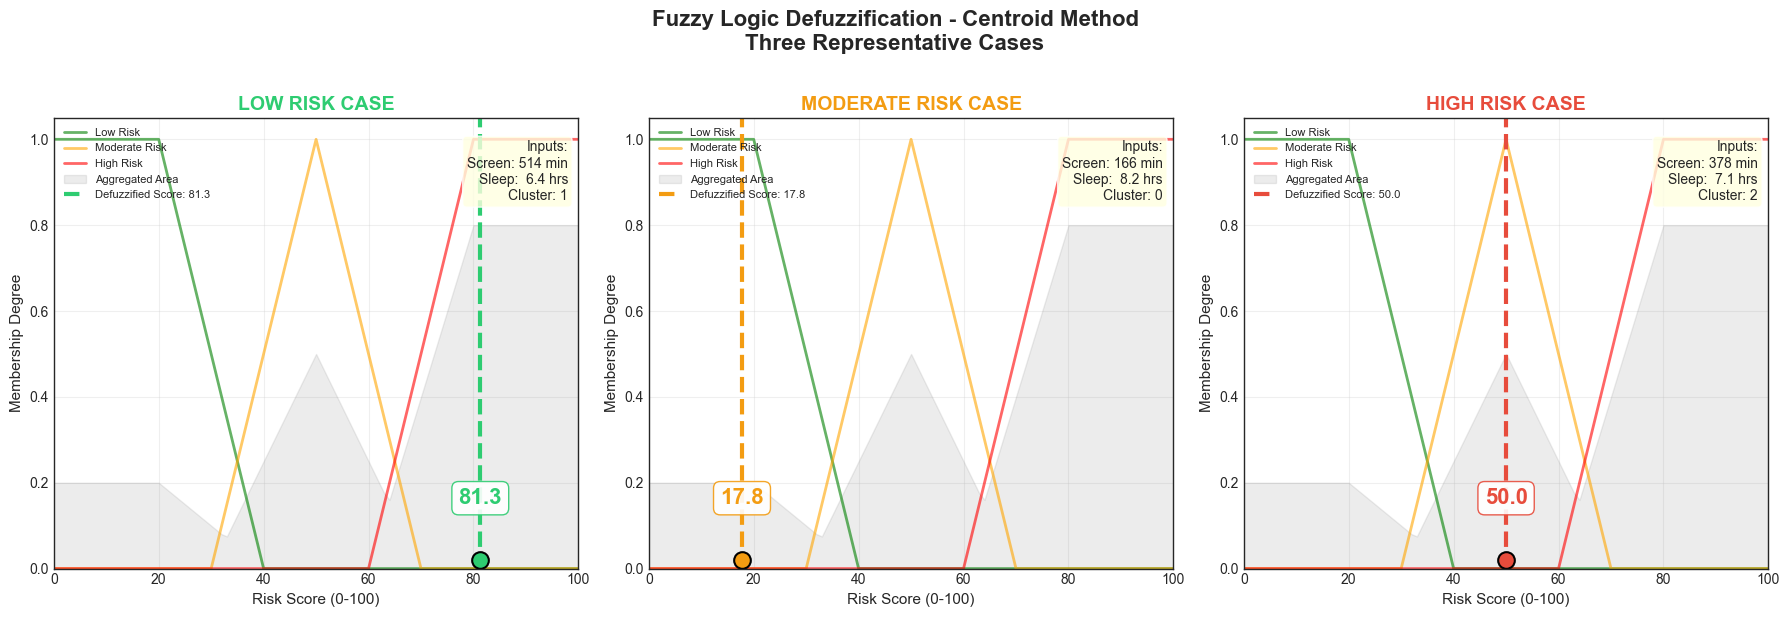


DEFUZZIFICATION CASE DETAILS

CASE 1 - LOW RISK:
  Screen Time:            514 min/day
  Sleep Hours:            6.4 hours
  Cluster:                1 (Healthy)
  Defuzzified Risk Score: 81.3
  → The centroid falls in the LOW RISK region
  → Recommendation: Maintain current habits

CASE 2 - MODERATE RISK:
  Screen Time:            166 min/day
  Sleep Hours:            8.2 hours
  Cluster:                0 (Moderate Stress)
  Defuzzified Risk Score: 17.8
  → The centroid falls in the MODERATE RISK region
  → Recommendation: Reduce screen time OR improve sleep

CASE 3 - HIGH RISK:
  Screen Time:            378 min/day
  Sleep Hours:            7.1 hours
  Cluster:                2 (High Risk)
  Defuzzified Risk Score: 50.0
  → The centroid falls in the HIGH RISK region
  → Recommendation: Immediate intervention needed



In [226]:
# ===================================================================
# REDEFINE RULES - 9 RULES, 2 INPUTS ONLY (screen_time + sleep_hours)
# cluster_input is used in VALIDATION only, not in rules
# ===================================================================

rule1 = ctrl.Rule(screen_time['low'] & sleep_hours['good'], risk_score['low_risk'])
rule2 = ctrl.Rule(screen_time['low'] & sleep_hours['adequate'], risk_score['low_risk'])
rule3 = ctrl.Rule(screen_time['low'] & sleep_hours['poor'], risk_score['moderate_risk'])
rule4 = ctrl.Rule(screen_time['moderate'] & sleep_hours['good'], risk_score['low_risk'])
rule5 = ctrl.Rule(screen_time['moderate'] & sleep_hours['adequate'], risk_score['moderate_risk'])
rule6 = ctrl.Rule(screen_time['moderate'] & sleep_hours['poor'], risk_score['high_risk'])
rule7 = ctrl.Rule(screen_time['high'] & sleep_hours['good'], risk_score['moderate_risk'])
rule8 = ctrl.Rule(screen_time['high'] & sleep_hours['adequate'], risk_score['high_risk'])
rule9 = ctrl.Rule(screen_time['high'] & sleep_hours['poor'], risk_score['high_risk'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

# ===================================================================
# DEFUZZIFICATION VISUALIZATION - THREE CASE STUDIES
# ===================================================================

risk_sim_low  = ctrl.ControlSystemSimulation(risk_ctrl)
risk_sim_mod  = ctrl.ControlSystemSimulation(risk_ctrl)
risk_sim_high = ctrl.ControlSystemSimulation(risk_ctrl)

low_case  = test_samples[3]   # Cluster 1 (Healthy)
mod_case  = test_samples[0]   # Cluster 0 (Moderate)
high_case = test_samples[-1]  # Cluster 2 (High Risk)

# Compute LOW RISK case
risk_sim_low.input['screen_time'] = low_case['screen_time']
risk_sim_low.input['sleep_hours'] = low_case['sleep_hours']
risk_sim_low.compute()

# Compute MODERATE RISK case
risk_sim_mod.input['screen_time'] = mod_case['screen_time']
risk_sim_mod.input['sleep_hours'] = mod_case['sleep_hours']
risk_sim_mod.compute()

# Compute HIGH RISK case
risk_sim_high.input['screen_time'] = high_case['screen_time']
risk_sim_high.input['sleep_hours'] = high_case['sleep_hours']
risk_sim_high.compute()

# ===================================================================
# CREATE THE THREE DEFUZZIFICATION PLOTS
# ===================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cases = [
    (axes[0], risk_sim_low,  low_case,  'LOW RISK CASE',      '#2ecc71'),
    (axes[1], risk_sim_mod,  mod_case,  'MODERATE RISK CASE', '#f39c12'),
    (axes[2], risk_sim_high, high_case, 'HIGH RISK CASE',     '#e74c3c'),
]

for ax, sim, case, title, defuzz_color in cases:

    ax.plot(risk_score.universe, risk_score['low_risk'].mf,
            'g', linewidth=2, alpha=0.6, label='Low Risk')
    ax.plot(risk_score.universe, risk_score['moderate_risk'].mf,
            'orange', linewidth=2, alpha=0.6, label='Moderate Risk')
    ax.plot(risk_score.universe, risk_score['high_risk'].mf,
            'r', linewidth=2, alpha=0.6, label='High Risk')

    try:
        score = sim.output['risk_score']
        ax.fill_between(risk_score.universe, 0,
                        np.maximum(np.maximum(
                            risk_score['low_risk'].mf * 0.2,
                            risk_score['moderate_risk'].mf * 0.5),
                            risk_score['high_risk'].mf * 0.8),
                        alpha=0.15, color='gray', label='Aggregated Area')
    except:
        score = 50

    ax.axvline(x=score, color=defuzz_color, linestyle='--', linewidth=3,
               label=f'Defuzzified Score: {score:.1f}')
    ax.plot(score, 0.02, 'o', color=defuzz_color, markersize=12,
            markeredgecolor='black', markeredgewidth=1.5)
    ax.annotate(f'{score:.1f}', xy=(score, 0.15),
                fontsize=16, fontweight='bold', color=defuzz_color, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=defuzz_color, alpha=0.9))

    input_text = (f"Inputs:\n"
                  f"Screen: {case['screen_time']:.0f} min\n"
                  f"Sleep:  {case['sleep_hours']:.1f} hrs\n"
                  f"Cluster: {case['cluster']}")
    ax.text(0.98, 0.95, input_text, transform=ax.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.set_title(title, fontsize=14, fontweight='bold', color=defuzz_color)
    ax.set_xlabel('Risk Score (0-100)', fontsize=11)
    ax.set_ylabel('Membership Degree', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.05)

plt.suptitle('Fuzzy Logic Defuzzification - Centroid Method\nThree Representative Cases',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fuzzy_defuzzification.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("DEFUZZIFICATION CASE DETAILS")
print("="*60)
print(f"""
CASE 1 - LOW RISK:
  Screen Time:            {low_case['screen_time']:.0f} min/day
  Sleep Hours:            {low_case['sleep_hours']:.1f} hours
  Cluster:                {low_case['cluster']} (Healthy)
  Defuzzified Risk Score: {risk_sim_low.output['risk_score']:.1f}
  → The centroid falls in the LOW RISK region
  → Recommendation: Maintain current habits

CASE 2 - MODERATE RISK:
  Screen Time:            {mod_case['screen_time']:.0f} min/day
  Sleep Hours:            {mod_case['sleep_hours']:.1f} hours
  Cluster:                {mod_case['cluster']} (Moderate Stress)
  Defuzzified Risk Score: {risk_sim_mod.output['risk_score']:.1f}
  → The centroid falls in the MODERATE RISK region
  → Recommendation: Reduce screen time OR improve sleep

CASE 3 - HIGH RISK:
  Screen Time:            {high_case['screen_time']:.0f} min/day
  Sleep Hours:            {high_case['sleep_hours']:.1f} hours
  Cluster:                {high_case['cluster']} (High Risk)
  Defuzzified Risk Score: {risk_sim_high.output['risk_score']:.1f}
  → The centroid falls in the HIGH RISK region
  → Recommendation: Immediate intervention needed
""")

In [227]:
# Task 7: System Implementation Pipeline

TASK 7: COMPREHENSIVE SYSTEM IMPLEMENTATION


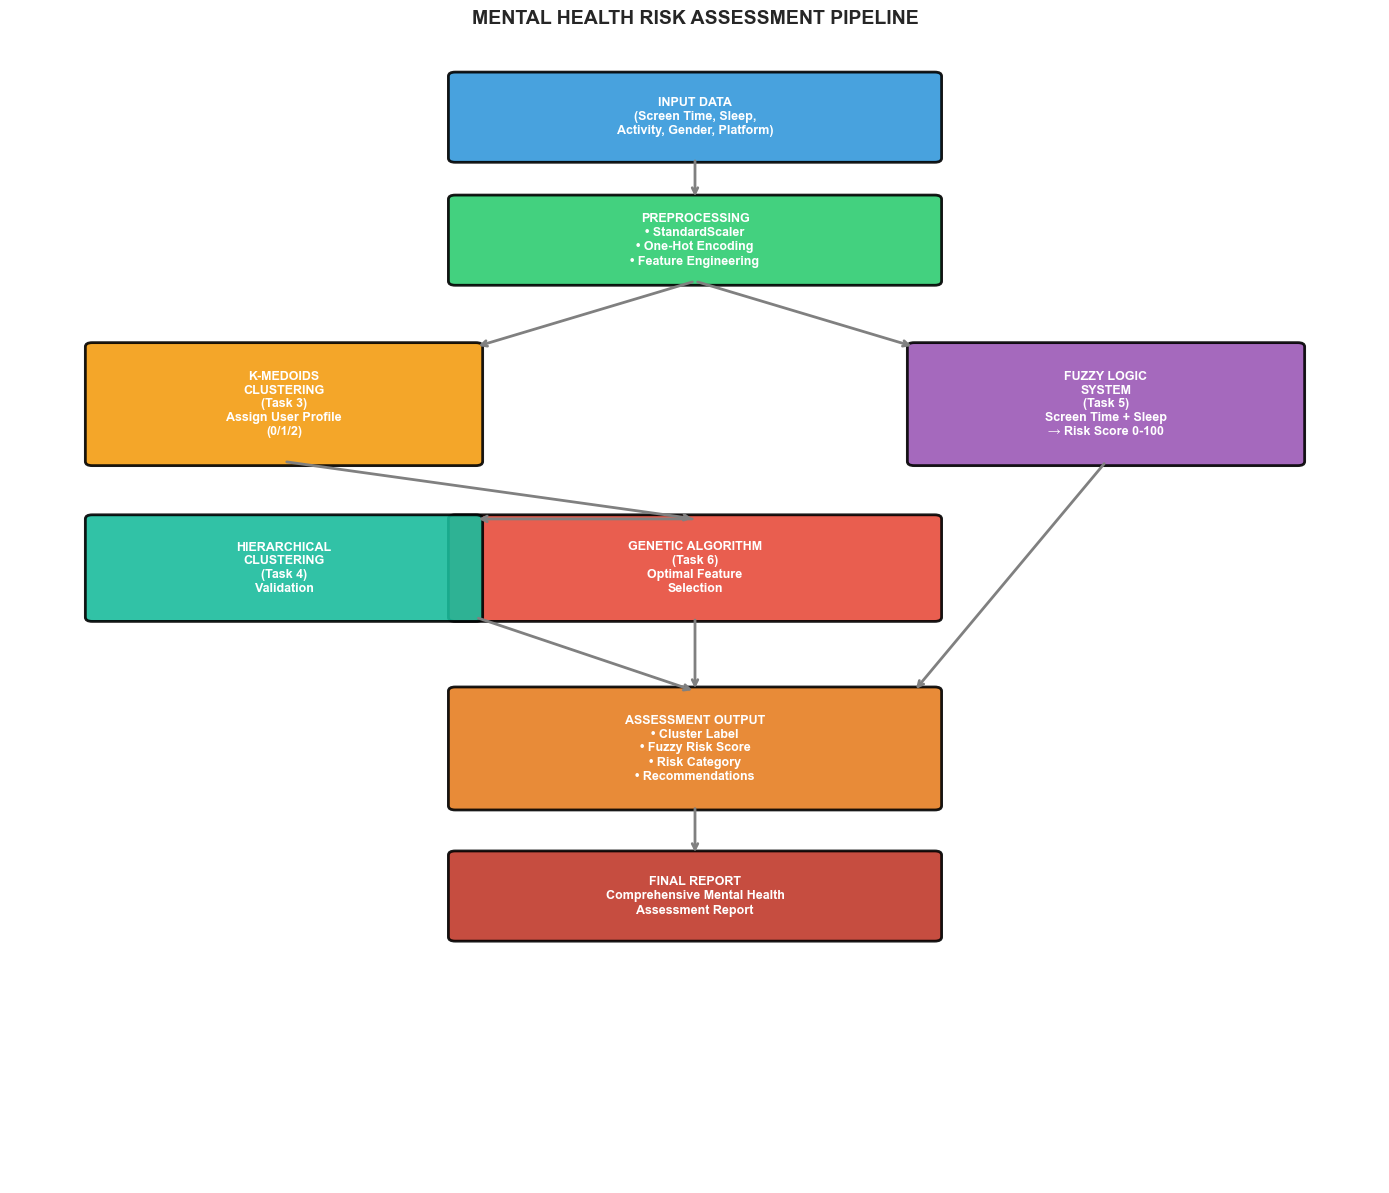

In [228]:
print("="*80)
print("TASK 7: COMPREHENSIVE SYSTEM IMPLEMENTATION")
print("="*80)

# ── PIPELINE FLOWCHART VISUALIZATION ──
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

boxes = [
    {'label': 'INPUT DATA\n(Screen Time, Sleep,\nActivity, Gender, Platform)', 
     'pos': (5, 13), 'size': (3.5, 1.0), 'color': '#3498db'},
    {'label': 'PREPROCESSING\n• StandardScaler\n• One-Hot Encoding\n• Feature Engineering', 
     'pos': (5, 11.5), 'size': (3.5, 1.0), 'color': '#2ecc71'},
    {'label': 'K-MEDOIDS\nCLUSTERING\n(Task 3)\nAssign User Profile\n(0/1/2)', 
     'pos': (2, 9.5), 'size': (2.8, 1.4), 'color': '#f39c12'},
    {'label': 'FUZZY LOGIC\nSYSTEM\n(Task 5)\nScreen Time + Sleep\n→ Risk Score 0-100', 
     'pos': (8, 9.5), 'size': (2.8, 1.4), 'color': '#9b59b6'},
    {'label': 'GENETIC ALGORITHM\n(Task 6)\nOptimal Feature\nSelection', 
     'pos': (5, 7.5), 'size': (3.5, 1.2), 'color': '#e74c3c'},
    {'label': 'HIERARCHICAL\nCLUSTERING\n(Task 4)\nValidation', 
     'pos': (2, 7.5), 'size': (2.8, 1.2), 'color': '#1abc9c'},
    {'label': 'ASSESSMENT OUTPUT\n• Cluster Label\n• Fuzzy Risk Score\n• Risk Category\n• Recommendations', 
     'pos': (5, 5.3), 'size': (3.5, 1.4), 'color': '#e67e22'},
    {'label': 'FINAL REPORT\nComprehensive Mental Health\nAssessment Report', 
     'pos': (5, 3.5), 'size': (3.5, 1.0), 'color': '#c0392b'},
]

for box in boxes:
    rect = FancyBboxPatch(
        (box['pos'][0] - box['size'][0]/2, box['pos'][1] - box['size'][1]/2),
        box['size'][0], box['size'][1],
        boxstyle="round,pad=0.05",
        facecolor=box['color'], edgecolor='black', linewidth=2, alpha=0.9
    )
    ax.add_patch(rect)
    ax.text(box['pos'][0], box['pos'][1], box['label'], 
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')

arrows = [
    ((5, 12.5), (5, 12.0)),
    ((5, 11.0), (3.4, 10.2)),
    ((5, 11.0), (6.6, 10.2)),
    ((2, 8.8), (5, 8.1)),
    ((5, 8.1), (3.4, 8.1)),
    ((8, 8.8), (6.6, 6.0)),
    ((3.4, 6.9), (5, 6.0)),
    ((5, 6.9), (5, 6.0)),
    ((5, 4.6), (5, 4.0)),
]

for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

ax.text(5, 14.2, 'MENTAL HEALTH RISK ASSESSMENT PIPELINE', 
        ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()

In [229]:
import numpy as np

# ===================================================================
# COMPREHENSIVE ASSESSMENT FUNCTION
# ===================================================================
class MentalHealthPipeline:
    def __init__(self, kmedoids_model, scaler_model, fuzzy_simulator, 
                 ga_features, model_columns, numerical_columns):
        self.kmedoids = kmedoids_model
        self.scaler = scaler_model
        self.fuzzy_sim = fuzzy_simulator
        self.ga_features = ga_features
        self.model_columns = model_columns
        self.numerical_columns = numerical_columns
    
    def assess(self, patient_data):
        result = {}
        
        # STEP 1: Build full feature vector
        gender = patient_data.get('gender', 'Male')
        platform = patient_data.get('platform', 'Instagram')
        
        full_vector_list = []
        for col in self.model_columns:
            if col in self.numerical_columns:
                full_vector_list.append(patient_data.get(col, 0))
            elif col.startswith('gender_'):
                full_vector_list.append(1 if col == f'gender_{gender}' else 0)
            elif col.startswith('platform_'):
                full_vector_list.append(1 if col == f'platform_{platform}' else 0)
            else:
                full_vector_list.append(0)
        
        full_vector = np.array(full_vector_list).astype(float)
        
        # Scaling
        num_len = len(self.numerical_columns)
        num_part = full_vector[:num_len]
        num_scaled = self.scaler.transform([num_part])[0]
        full_vector[:num_len] = num_scaled
        
        # Filter for the specific features your model expects (the 9 GA features)
        model_input_indices = [i for i, col in enumerate(self.model_columns) if col in self.ga_features]
        model_input_vector = full_vector[model_input_indices]
        
        # STEP 2: Cluster Prediction
        cluster = self.kmedoids.predict(model_input_vector.reshape(1, -1))[0]
        cluster_labels = {
            0: "Moderate Stress - Functional",
            1: "Healthy - Low Digital Risk",
            2: "High Risk - Severe Digital Stress"
        }
        result['cluster_label'] = cluster_labels.get(cluster, f"Cluster {cluster}")
        
        # STEP 3: Fuzzy Risk Score
        screen = patient_data.get('daily_screen_time_min', 300)
        sleep = patient_data.get('sleep_hours', 7)
        
        try:
            # SAFETY: Clip values to stay within fuzzy universe ranges (usually 0-1000 for screen, 0-24 for sleep)
            self.fuzzy_sim.input['screen_time'] = np.clip(screen, 0, 1000) 
            self.fuzzy_sim.input['sleep_hours'] = np.clip(sleep, 0, 24)
            self.fuzzy_sim.compute()
            risk_score = self.fuzzy_sim.output['risk_score']
        except Exception:
            # Mathematical Fallback if Fuzzy fails
            risk_score = min(100, max(0, (screen/500*60) + ((8-sleep)/3*40)))
        
        result['risk_score'] = round(float(risk_score), 1)
        result['risk_category'] = "High Risk" if risk_score > 65 else "Moderate Risk" if risk_score > 35 else "Low Risk"
        
        # STEP 4: Recommendations & Report
        activity = patient_data.get('physical_activity_min', 30)
        anxiety = patient_data.get('anxiety_level', 2)
        
        recs = [f"Maintain healthy lifestyle"] if result['risk_score'] < 35 else [f"Seek professional support"]
        if screen > 300: recs.append("Reduce screen time")
        if sleep < 7: recs.append("Improve sleep hygiene")
        
        result['report'] = f"""
╔══════════════════════════════════════════════╗
║      MENTAL HEALTH ASSESSMENT REPORT         ║
╠══════════════════════════════════════════════╣
║  CLUSTER:  {result['cluster_label']:<33} ║
║  RISK:     {result['risk_score']:.1f}/100 ({result['risk_category']})          ║
║  Screen: {screen:<5} | Sleep: {sleep:<5} | Anxiety: {anxiety}/4  ║
╚══════════════════════════════════════════════╝"""
        result['recommendations'] = recs
        return result

# ===================================================================
# EXECUTION LOOP
# ===================================================================

# (Make sure your variables kmedoids_final, scaler, risk_sim, etc. are loaded)
pipeline = MentalHealthPipeline(kmedoids_final, scaler, risk_sim, best_features, model_columns, numerical_columns)

for label, patient in patients.items():
    try:
        print(f"\n--- TESTING: {label} ---")
        res = pipeline.assess(patient)
        print(res['report'])
        print("Recommendations:", ", ".join(res['recommendations']))
    except Exception as e:
        print(f"Error processing {label}: {e}")


--- TESTING: HEALTHY ---

╔══════════════════════════════════════════════╗
║      MENTAL HEALTH ASSESSMENT REPORT         ║
╠══════════════════════════════════════════════╣
║  CLUSTER:  Moderate Stress - Functional      ║
║  RISK:     16.9/100 (Low Risk)          ║
║  Screen: 160   | Sleep: 8.5   | Anxiety: 1/4  ║
╚══════════════════════════════════════════════╝
Recommendations: Maintain healthy lifestyle

--- TESTING: MODERATE ---

╔══════════════════════════════════════════════╗
║      MENTAL HEALTH ASSESSMENT REPORT         ║
╠══════════════════════════════════════════════╣
║  CLUSTER:  Moderate Stress - Functional      ║
║  RISK:     50.0/100 (Moderate Risk)          ║
║  Screen: 370   | Sleep: 7.0   | Anxiety: 3/4  ║
╚══════════════════════════════════════════════╝
Recommendations: Seek professional support, Reduce screen time

--- TESTING: HIGH RISK ---

╔══════════════════════════════════════════════╗
║      MENTAL HEALTH ASSESSMENT REPORT         ║
╠═══════════════════════════

In [230]:

print(f"""
\n{'='*70}
PIPELINE FLOW CHART
{'='*70}
┌─────────────────────────────────────────────────────────────────────────────┐
│                         MENTAL HEALTH ANALYSIS PIPELINE                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────┐ │
│  │   RAW DATA   │───▶│ PREPROCESSING │───▶│   FEATURE    │───▶│ K-MEDOIDS  │ │
│  │   RECORD     │    │  & SCALING   │    │ ENGINEERING  │    │ CLUSTERING │ │
│  └──────────────┘    └──────────────┘    └──────────────┘    └────────────┘ │
│                                                                      │       │
│                                                                      ▼       │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────┐ │
│  │   FINAL      │◀───│   INSIGHT    │◀───│    FUZZY     │◀───│  CLUSTER   │ │
│  │   REPORT     │    │  GENERATION  │    │   LOGIC      │    │  PROFILE   │ │
│  └──────────────┘    └──────────────┘    └──────────────┘    └────────────┘ │
│                                                                              │
│  SUPPORTING COMPONENTS:                                                      │
│  ┌──────────────────────────────────────────────────────────────────────┐   │
│  │  GENETIC ALGORITHM (Task 6) ──▶ Feature Selection ──▶ Optimal Subset │   │
│  │  HIERARCHICAL CLUSTERING (Task 4) ──▶ Validation ──▶ Confirms k=3    │   │
│  └──────────────────────────────────────────────────────────────────────┘   │
│                                                                              │
├─────────────────────────────────────────────────────────────────────────────┤
│  PIPELINE STAGES:                                                            │
│  1. DATA INPUT: Patient demographics, behaviors, and mental health metrics   │
│  2. PREPROCESSING: StandardScaler + One-Hot Encoding (27-dim vector)         │
│  3. K-MEDOIDS: Assigns to Cluster 0 (Moderate), 1 (Healthy), 2 (High Risk)  │
│  4. FUZZY LOGIC: Calculates risk score (0-100) from screen time + sleep      │
│  5. RECOMMENDATIONS: Personalized based on risk category and metrics         │
│  6. REPORT: Formatted assessment with cluster, risk, and recommendations     │
└─────────────────────────────────────────────────────────────────────────────┘

OUTPUT TRANSLATION:
• Cluster 0 → "Moderate Stress - Functional" → Preventive measures
• Cluster 1 → "Healthy - Low Digital Risk" → Maintain habits
• Cluster 2 → "High Risk - Severe Digital Stress" → Urgent intervention
• Risk Score 0-35 → Low Risk | 35-65 → Moderate Risk | 65-100 → High Risk
{"="*70}
""")



PIPELINE FLOW CHART
┌─────────────────────────────────────────────────────────────────────────────┐
│                         MENTAL HEALTH ANALYSIS PIPELINE                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────┐ │
│  │   RAW DATA   │───▶│ PREPROCESSING │───▶│   FEATURE    │───▶│ K-MEDOIDS  │ │
│  │   RECORD     │    │  & SCALING   │    │ ENGINEERING  │    │ CLUSTERING │ │
│  └──────────────┘    └──────────────┘    └──────────────┘    └────────────┘ │
│                                                                      │       │
│                                                                      ▼       │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────┐ │
│  │   FINAL      │◀───│   INSIGHT    │◀───│    FUZZY     │◀───│  CLUSTER   │ │
│  │   REPOR